# ANÁLISIS COMPLETO FINGER TAPPING — MDS-UPDRS 3.4
## Pipeline: Extracción → Inferencial → Discriminabilidad

**Estructura del pipeline:**
1. Extracción de features (misma lógica del notebook baseline, ahora para todos los scores)
2. Consolidación del dataset con etiquetas de score y sujeto
3. Análisis descriptivo por score
4. Análisis inferencial (Kruskal-Wallis + tamaños de efecto)
5. Análisis de discriminabilidad (LDA + LOSO + AUC/ROC)
6. Exportación de resultados

**Diseño del estudio:**
- Score 0: 23 personas sanas (15 × 6 pruebas + 8 × 4 pruebas = 122 pruebas)
- Scores 1–4: 3 sujetos simulando cada nivel, 10 pruebas c/u (30 pruebas por score)
- Manos: derecha e izquierda (archivos separados por nombre)
- Tarea: Finger Tapping MDS-UPDRS ítem 3.4

**Convención de nombres de archivo esperada:**
```
score0/GA_01_right_01.json  → Score 0, sujeto GA_01, mano derecha, prueba 1
score1/P01_left_03.json     → Score 1, sujeto P01, mano izquierda, prueba 3
```
El score se infiere de la carpeta. El sujeto, mano y prueba del nombre del archivo.

---
## CELDA 1 — Imports y configuración

In [2]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
============================================================================
"""

import json
import os
import re
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.stats import kruskal, mannwhitneyu

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, accuracy_score,
    matthews_corrcoef
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar rutas aquí
# ─────────────────────────────────────────────
class Config:
    # Raíz del dataset: debe contener subcarpetas score0/, score1/, ..., score4/
    # Cada subcarpeta con archivos .json de las pruebas
    RUTA_DATOS = "./FINGER_TAPPING"  # <── AJUSTAR
    
    # Carpeta de salida para todos los resultados
    RUTA_SALIDA = "./resultados_golpeteo_completo"
    
    # ── Señal ──
    FS = 100           # Hz objetivo
    FS_TOLERANCE = 0.20
    
    # ── Filtros ──
    GYRO_LOWCUT  = 0.5   # Hz
    GYRO_HIGHCUT = 8.0   # Hz
    ACCEL_CUTOFF = 5.0   # Hz
    
    # ── Detección de taps ──
    PICO_PROMINENCE_FACTOR = 0.1
    PICO_HEIGHT_FACTOR_POS = 0.1
    PICO_HEIGHT_FACTOR_NEG = 0.1
    PICO_MIN_DISTANCE = 10   # muestras (100 ms a 100 Hz)
    PICO_WIDTH        = 4
    N_CICLOS_ESPERADOS = 10
    USAR_TOP_N        = True
    UMBRAL_HESITACION = 1.5
    
    # ── Validación ──
    CICLOS_MIN_VALIDOS = 6   # mínimo de taps para considerar prueba válida
    DURACION_MINIMA    = 3.0 # segundos
    
    # ── Scores presentes en el dataset ──
    SCORES = [0, 1, 2, 3, 4]
    
    # ── Features para análisis (subset más discriminativo) ──
        # ── Features para análisis (subset más discriminativo) ──
    FEATURES_ANALISIS = [
        'frecuencia', 'cadencia',
        'amplitud_media', 'amplitud_cv', 'amplitud_max',
        'amplitud_angular_media',
        'iti_media', 'iti_cv', 'iti_std',
        'decremento_pct', 'decremento_pendiente',
        'n_hesitaciones',
        'jerk_rms', 'jerk_rms_angular',
        'rms_acc_lateral', 'energia_relativa_dom',
        'velocidad_pico_media', 'compensacion_lateral'
    ]


os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

print("✅ Configuración cargada")
print(f"   Ruta datos : {Config.RUTA_DATOS}")


✅ Configuración cargada
   Ruta datos : ./FINGER_TAPPING


---
## CELDA 2 — Funciones de procesamiento de señal (motor de extracción)

In [3]:
"""
============================================================================
MOTOR DE PROCESAMIENTO IMU → FEATURES  —  FINGER TAPPING (MDS-UPDRS 3.4)

Emite EXACTAMENTE las 20 features del modelo LDA:
  frecuencia, cadencia, amplitud_media, amplitud_cv, amplitud_max,
  amplitud_angular_media, iti_media, iti_cv, iti_std, regularidad,
  regularidad_ritmica, decremento_pct, decremento_pendiente, n_hesitaciones,
  jerk_rms, jerk_rms_angular, rms_acc_lateral, energia_relativa_dom,
  velocidad_pico_media, compensacion_lateral
============================================================================
"""

import os
import json
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# ── Utilidades de señal ──────────────────────────────────────────────────

def butter_bandpass(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def butter_lowpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)

def butter_highpass(data, cutoff, fs, order=1):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, data)

def eliminar_duplicados_tiempo(time, signals_dict):
    _, idx = np.unique(time, return_index=True)
    idx = np.sort(idx)
    return time[idx], {k: v[idx] for k, v in signals_dict.items()}

def remuestrear_uniforme(time, signals_dict, fs_target):
    time, signals_dict = eliminar_duplicados_tiempo(time, signals_dict)
    if len(time) < 4:
        return None, None
    n = int((time[-1] - time[0]) * fs_target) + 1
    if n < 4:
        return None, None
    t_uni = np.linspace(time[0], time[-1], n)
    resampled = {}
    for k, v in signals_dict.items():
        f = interp1d(time, v, kind='cubic', fill_value='extrapolate')
        resampled[k] = f(t_uni)
    return t_uni, resampled

def detectar_eje_dominante(signals_filt):
    gyro  = {k: np.var(v) for k, v in signals_filt.items() if k.startswith('g')}
    accel = {k: np.var(v) for k, v in signals_filt.items() if k.startswith('a')}
    eje_g = max(gyro,  key=gyro.get)  if gyro  else 'gx'
    eje_a = max(accel, key=accel.get) if accel else 'ax'
    return eje_g, eje_a

# ── Detección de taps ────────────────────────────────────────────────────

def seleccionar_top_n_picos(picos_pos, picos_neg, signal, n):
    def amp_rel(picos):
        amps = np.abs(signal[picos])
        med  = np.median(amps)
        return np.minimum(amps / med if med > 0 else amps, 3.0)
    if len(picos_pos) > n:
        idx = np.argsort(amp_rel(picos_pos))[::-1][:n]
        picos_pos = np.sort(picos_pos[idx])
    if len(picos_neg) > n:
        idx = np.argsort(amp_rel(picos_neg))[::-1][:n]
        picos_neg = np.sort(picos_neg[idx])
    return picos_pos, picos_neg

def emparejar_taps(picos_pos, picos_neg, time, signal, angle_signal):
    if len(picos_pos) == 0 or len(picos_neg) == 0:
        return []
    candidatos = sorted(
        [(abs(time[p] - time[n]), i, j, p, n)
         for i, p in enumerate(picos_pos)
         for j, n in enumerate(picos_neg)],
        key=lambda x: x[0]
    )
    usados_p, usados_n, pares = set(), set(), []
    for dist, i, j, p, n in candidatos:
        if i in usados_p or j in usados_n:
            continue
        usados_p.add(i); usados_n.add(j)
        pares.append({
            'pos_idx': p, 'neg_idx': n,
            'amplitud': abs(signal[p] - signal[n]),
            'amplitud_angular': abs(angle_signal[p] - angle_signal[n]),
            'tiempo_medio': (time[p] + time[n]) / 2.0
        })
    return sorted(pares, key=lambda x: x['tiempo_medio'])

def detectar_ciclos(signal, angle_signal, time_signal, cfg):
    prom = (np.max(signal) - np.min(signal)) * cfg.PICO_PROMINENCE_FACTOR
    pp, _ = find_peaks(
        signal, prominence=prom, distance=cfg.PICO_MIN_DISTANCE,
        height=np.max(signal)*cfg.PICO_HEIGHT_FACTOR_POS, width=cfg.PICO_WIDTH
    )
    pn, _ = find_peaks(
        -signal, prominence=prom, distance=cfg.PICO_MIN_DISTANCE,
        height=abs(np.min(signal))*cfg.PICO_HEIGHT_FACTOR_NEG, width=cfg.PICO_WIDTH
    )
    todos = sorted(
        [('+', int(p), signal[p]) for p in pp] +
        [('-', int(n), signal[n]) for n in pn],
        key=lambda x: x[1]
    )
    fp, fn, ut, ui, uv = [], [], None, None, None
    for tipo, idx, val in todos:
        if ut is None:
            ut, ui, uv = tipo, idx, val
        elif tipo != ut:
            (fp if ut=='+' else fn).append(ui)
            ut, ui, uv = tipo, idx, val
        else:
            if abs(val) > abs(uv): ui, uv = idx, val
    if ut: (fp if ut=='+' else fn).append(ui)
    pp = np.array(fp, dtype=int)
    pn = np.array(fn, dtype=int)
    if cfg.USAR_TOP_N and cfg.N_CICLOS_ESPERADOS > 0:
        pp, pn = seleccionar_top_n_picos(pp, pn, signal, cfg.N_CICLOS_ESPERADOS)
    taps = emparejar_taps(pp, pn, time_signal, signal, angle_signal)
    return pp, pn, len(taps), taps

# ── Decremento robusto ────────────────────────────────────────────────────

def analizar_decremento(amplitudes, tiempos):
    if len(amplitudes) < 3:
        return 0.0, 0.0, 0.0, False
    amps = np.array(amplitudes); ts = np.array(tiempos)
    z = np.polyfit(ts, amps, 1)
    pred = np.poly1d(z)(ts)
    ss_res = np.sum((amps-pred)**2)
    ss_tot = np.sum((amps-np.mean(amps))**2)
    r2 = 1-(ss_res/ss_tot) if ss_tot > 0 else 0.0
    n = len(amps); t = max(1, n//3)
    ini = np.median(amps[:t]); fin = np.median(amps[-t:])
    dec_pct = ((ini-fin)/ini*100) if ini > 0 else 0.0
    hay_dec = (dec_pct > 15) and (z[0] < 0) and (r2 > 0.1)
    return float(z[0]), float(r2), float(dec_pct), bool(hay_dec)

# ── Pipeline principal: JSON → features dict ─────────────────────────────

def procesar_json_a_features(json_path, cfg):
    """
    Carga un archivo JSON de IMU y retorna un dict con EXACTAMENTE las
    20 features que el modelo LDA de Finger Tapping espera.
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
    except Exception as e:
        print(f"  ✗ Error cargando {os.path.basename(json_path)}: {e}")
        return None

    if isinstance(raw, list):
        imu_data = raw
    elif isinstance(raw, dict):
        imu_data = raw.get('imuData', raw.get('data', []))
    else:
        return None

    if len(imu_data) < 50:
        return None

    dispositivos = {}
    for d in imu_data:
        did = d.get('deviceId', 'device0')
        dispositivos.setdefault(did, []).append(d)
    datos = list(dispositivos.values())[0]

    time = np.array([d['timestamp'] for d in datos])
    time = (time - time[0]) / 1000.0
    sig_raw = {
        'gx': np.array([d.get('gyroscope',{}).get('x',0) for d in datos]),
        'gy': np.array([d.get('gyroscope',{}).get('y',0) for d in datos]),
        'gz': np.array([d.get('gyroscope',{}).get('z',0) for d in datos]),
        'ax': np.array([d.get('accelerometer',{}).get('x',0) for d in datos]),
        'ay': np.array([d.get('accelerometer',{}).get('y',0) for d in datos]),
        'az': np.array([d.get('accelerometer',{}).get('z',0) for d in datos]),
    }

    dt_real = np.median(np.diff(time))
    fs_real = 1.0/dt_real if dt_real > 0 else cfg.FS

    time, sig = remuestrear_uniforme(time, sig_raw, fs_real)
    if time is None:
        return None
    dt = 1.0 / fs_real

    # Filtros
    sig_f = {}
    for k in ['gx','gy','gz']: sig_f[k] = butter_bandpass(sig[k], cfg.GYRO_LOWCUT, cfg.GYRO_HIGHCUT, fs_real)
    for k in ['ax','ay','az']: sig_f[k] = butter_lowpass(sig[k], cfg.ACCEL_CUTOFF, fs_real)

    # Ejes dominantes
    eje_g_dom, eje_a_dom = detectar_eje_dominante(sig_f)

    # Señal de detección: ángulo integrado del eje dominante
    ang_comp = {
        k: np.insert(np.cumsum(0.5*(v[:-1]+v[1:])) * dt, 0, 0.0)
        for k, v in sig_f.items() if k.startswith('g')
    }
    sig_dom = ang_comp[eje_g_dom]

    # Ángulo integrado con filtro de deriva (para amplitud_angular_media)
    gx_for_angle = butter_lowpass(sig[eje_g_dom.replace('g','g')], cfg.GYRO_HIGHCUT, fs_real)
    gx_for_angle = gx_for_angle - np.mean(gx_for_angle)
    angle_raw = np.insert(np.cumsum(0.5 * (gx_for_angle[:-1] + gx_for_angle[1:])) * dt, 0, 0.0)
    angulo_dom = butter_highpass(angle_raw, 0.05, fs_real, order=1)

    # Detección de taps
    pp, pn, n_taps, taps = detectar_ciclos(sig_dom, angulo_dom, time, cfg)

    # Features de ciclos
    amps     = [t['amplitud'] for t in taps]
    amps_ang = [t['amplitud_angular'] for t in taps]
    t_meds   = [t['tiempo_medio'] for t in taps]
    it_raw   = np.diff(t_meds) if len(t_meds) > 1 else []

    # Depuración de ITIs + hesitaciones
    iti_val = []
    hesitaciones = 0
    if len(it_raw) > 0:
        med_it = np.median(it_raw)
        iti_val = [i for i in it_raw if i < med_it * cfg.UMBRAL_HESITACION]
        hesitaciones = sum(1 for i in it_raw if i >= med_it * cfg.UMBRAL_HESITACION)

    # FFT sobre señal angular integrada
    N = len(sig_dom)
    yf = fft(sig_dom)
    xf = fftfreq(N, dt)[:N//2]
    pw = np.abs(yf[:N//2])
    f_dom = xf[np.argmax(pw[1:])+1] if len(pw) > 1 else 0.0

    # Cadencia
    cadencia = 1.0 / np.mean(it_raw) if len(it_raw) > 0 and np.mean(it_raw) > 0 else 0.0

    # CV amplitud
    cv_amp = np.std(amps)/np.mean(amps) if amps and np.mean(amps) > 0 else 0.0

    # Regularidad de amplitud: (1 - CV_amp) × 100
    regularidad = max(0.0, min(100.0, (1 - cv_amp) * 100))

    # Regularidad rítmica: (1 - CV_iti) × 100
    iti_cv = float(np.std(iti_val)/np.mean(iti_val)) if len(iti_val) > 0 and np.mean(iti_val) > 0 else 0.0
    regularidad_ritmica = max(0.0, min(100.0, (1 - iti_cv) * 100))

    # Decremento
    slope, r2, dec_p, hay_dec = analizar_decremento(amps, t_meds)

    # Compensación lateral gyro (ejes NO dominantes)
    lat_g = [v for k,v in sig_f.items() if k.startswith('g') and k != eje_g_dom]
    c_lat = float(np.std(np.concatenate([v.reshape(-1) for v in lat_g]))) if lat_g else 0.0

    # RMS acc lateral (ejes accel NO dominantes)
    lat_a = [v for k,v in sig_f.items() if k.startswith('a') and k != eje_a_dom]
    rms_acc_lat = float(np.sqrt(np.mean(np.sum([e**2 for e in lat_a], axis=0)))) if lat_a else 0.0

    # Jerk
    j_ang = np.gradient(sig_f[eje_g_dom], dt)
    j_lin = np.gradient(sig_f[eje_a_dom], dt)

    # Energía relativa
    e_dom   = float(np.mean(sig_f[eje_g_dom] ** 2))
    e_total = float(np.mean(sig_f['gx']**2) + np.mean(sig_f['gy']**2) + np.mean(sig_f['gz']**2))
    e_rel   = e_dom / e_total if e_total > 0 else 0.0

    # Velocidad pico
    vel_pico = [abs(sig_f[eje_g_dom][p]) for p in pp] + [abs(sig_f[eje_g_dom][p]) for p in pn]

    # ══════════════════════════════════════════════════════════════════
    # RETORNO: exactamente las 20 features del joblib, mismos nombres
    # ══════════════════════════════════════════════════════════════════
    duracion = time[-1] - time[0]
    valido   = (n_taps >= cfg.CICLOS_MIN_VALIDOS) and (duracion >= cfg.DURACION_MINIMA)

    return {
        'archivo':  os.path.basename(json_path),
        'valido':   valido,
        'n_taps':   n_taps,
        'duracion': duracion,
        'frecuencia':             float(f_dom),
        'cadencia':               float(cadencia),
        'amplitud_media':         float(np.mean(amps)) if amps else 0.0,
        'amplitud_cv':            float(cv_amp),
        'amplitud_max':           float(np.max(amps)) if amps else 0.0,
        'amplitud_angular_media': float(np.mean(amps_ang)) if amps_ang else 0.0,
        'iti_media':              float(np.mean(it_raw)) if len(it_raw) > 0 else 0.0,
        'iti_cv':                 float(iti_cv),
        'iti_std':                float(np.std(iti_val)) if len(iti_val) > 0 else 0.0,
        'regularidad':            float(regularidad),
        'regularidad_ritmica':    float(regularidad_ritmica),
        'decremento_pct':         float(dec_p),
        'decremento_pendiente':   float(slope),
        'n_hesitaciones':         int(hesitaciones),
        'jerk_rms':               float(np.sqrt(np.mean(j_lin**2))),
        'jerk_rms_angular':       float(np.sqrt(np.mean(j_ang**2))),
        'rms_acc_lateral':        float(rms_acc_lat),
        'energia_relativa_dom':   float(e_rel),
        'velocidad_pico_media':   float(np.mean(vel_pico)) if vel_pico else 0.0,
        'compensacion_lateral':   float(c_lat),
    }

print("✅ Motor de extracción finger tapping listo")


✅ Motor de extracción finger tapping listo


---
## CELDA 3 — Carga y consolidación del dataset completo

In [4]:
"""
============================================================================
CARGA DE TODOS LOS ARCHIVOS JSON Y CONSTRUCCIÓN DEL DATAFRAME MAESTRO
============================================================================
"""

def extraer_metadatos(json_data):
    """Extrae sujeto del JSON cargado."""
    # Score ya no lo sacamos de aquí para priorizar la carpeta
    
    # Sujeto
    sujeto = json_data.get('patient', {}).get('id', 'unknown')
    return sujeto


def cargar_dataset_completo(cfg):
    filas = []
    resumen = []
    
    for score in cfg.SCORES:
        carpeta = os.path.join(cfg.RUTA_DATOS, f'Score {score}')
        if not os.path.isdir(carpeta):
            print(f"  ⚠️  Carpeta no encontrada: {carpeta}")
            continue

        archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith('.json')])
        ok = invalido = error = 0
        
        for fname in archivos:
            fpath = os.path.join(carpeta, fname)
            
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    raw = json.load(f)
            except Exception as e:
                error += 1
                continue
                
            sujeto = extraer_metadatos(raw)
            
            imu_data = raw.get('imuData', raw.get('data', []))
            if not imu_data:
                error += 1
                continue
                
            # Agrupar por deviceId para procesar cada mano
            dispositivos = {}
            for d in imu_data:
                did = d.get('deviceId', 'unknown')
                dispositivos.setdefault(did, []).append(d)
                
            for did, datos in dispositivos.items():
                if 'RIGHT' in did.upper() or 'DERECHA' in did.upper():
                    mano = 'right'
                elif 'LEFT' in did.upper() or 'IZQUIERDA' in did.upper():
                    mano = 'left'
                else:
                    mano = 'unknown'
                    
                # Crear archivo temporal con los datos de esta mano
                # para no alterar procesar_json_a_features
                temp_path = f"temp_imu_{sujeto}_{mano}.json"
                try:
                    with open(temp_path, 'w', encoding='utf-8') as f:
                        json.dump(datos, f)
                    
                    feats = procesar_json_a_features(temp_path, cfg)
                finally:
                    if os.path.exists(temp_path):
                        os.remove(temp_path)
                
                if feats is None:
                    error += 1
                    continue
                    
                feats['score']    = int(score)
                feats['sujeto']   = sujeto
                feats['mano']     = mano
                feats['n_prueba'] = 1  # Ajustar si se cruzan pruebas del mismo sujeto
                
                if feats['valido']:
                    filas.append(feats)
                    ok += 1
                else:
                    invalido += 1
                
        resumen.append({'score': score, 'total': len(archivos),
                        'válidos': ok, 'inválidos': invalido, 'errores': error})
        print(f"  Score {score}: {len(archivos)} archivos → {ok} válidos, {invalido} inválidos, {error} errores")
        
    return pd.DataFrame(filas), pd.DataFrame(resumen)


print("🔄 Cargando dataset...")
df_master, df_resumen_carga = cargar_dataset_completo(Config)

print(f"\n{'='*60}")
print(f"DATASET CARGADO: {len(df_master)} pruebas válidas")
print(f"{'='*60}")
if not df_resumen_carga.empty:
    print(df_resumen_carga.to_string(index=False))
    print(f"\nScores presentes : {sorted(df_master['score'].unique())}")
    print(f"Sujetos únicos   : {df_master['sujeto'].nunique()}")
    print(f"Manos            : {df_master['mano'].unique().tolist()}")
    print(f"Features         : {len(Config.FEATURES_ANALISIS)}")

    print("\nPruebas por score × mano:")
    print(df_master.groupby(['score','mano']).size().unstack(fill_value=0).to_string())

    csv_path = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro.csv"
    df_master.to_csv(csv_path, index=False)
    print(f"\n💾 Dataset guardado: {csv_path}")
else:
    print("⚠️ No se cargaron datos válidos.")

🔄 Cargando dataset...


  Score 0: 93 archivos → 132 válidos, 51 inválidos, 2 errores
  Score 1: 30 archivos → 50 válidos, 10 inválidos, 0 errores
  Score 2: 30 archivos → 44 válidos, 15 inválidos, 1 errores
  Score 3: 30 archivos → 47 válidos, 13 inválidos, 0 errores
  Score 4: 29 archivos → 47 válidos, 11 inválidos, 0 errores

DATASET CARGADO: 320 pruebas válidas
 score  total  válidos  inválidos  errores
     0     93      132         51        2
     1     30       50         10        0
     2     30       44         15        1
     3     30       47         13        0
     4     29       47         11        0

Scores presentes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Sujetos únicos   : 20
Manos            : ['right', 'left']
Features         : 18

Pruebas por score × mano:
mano   left  right
score             
0        66     66
1        26     24
2        24     20
3        25     22
4        27     20

💾 Dataset guardado: ./resultados_golpeteo_completo/tablas/dataset_maes

---
## CELDA 4 — Análisis descriptivo por score

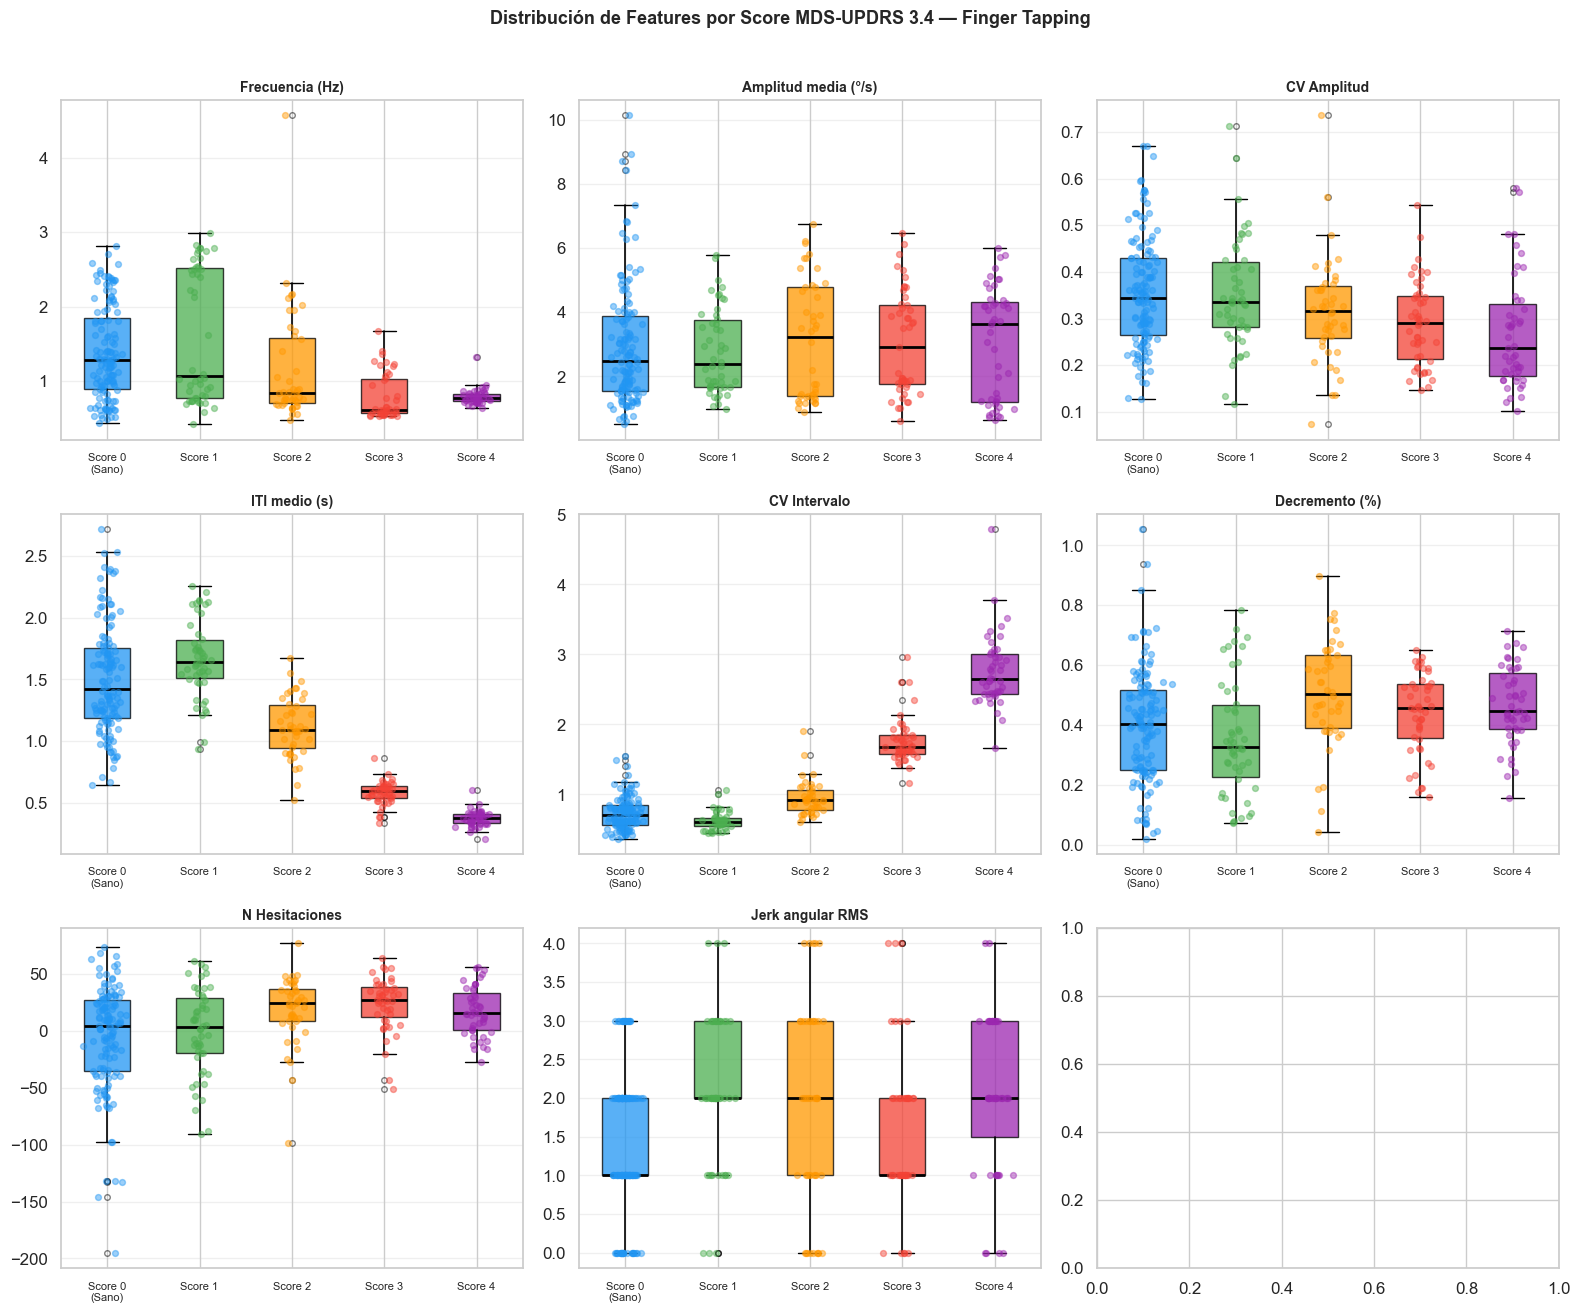

✅ Boxplots guardados

📊 Estadísticos para features principales:


In [5]:
"""
============================================================================
ANÁLISIS DESCRIPTIVO
Mediana, IQR y rango por score para cada feature clave.
Visualización: boxplots y tabla de estadísticos.
============================================================================
"""

FEATURES_PLOT = [
    'frecuencia', 'amplitud_media', 'amplitud_cv',
    'cadencia', 'iti_media', 'iti_cv',
    'decremento_pct', 'n_hesitaciones', 'jerk_rms_angular'
]

LABELS_PLOT = [
    'Frecuencia (Hz)', 'Amplitud media (°/s)', 'CV Amplitud',
    'ITI medio (s)', 'CV Intervalo',
    'Decremento (%)', 'N Hesitaciones', 'Jerk angular RMS'
]

SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
SCORE_LABELS = {0:'Score 0\n(Sano)', 1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4'}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(FEATURES_PLOT, LABELS_PLOT)):
    ax = axes[i]
    data_por_score = [df_master[df_master['score']==s][feat].dropna().values
                      for s in Config.SCORES]
    
    bp = ax.boxplot(data_por_score,
                    labels=[SCORE_LABELS[s] for s in Config.SCORES],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    
    for patch, score in zip(bp['boxes'], Config.SCORES):
        patch.set_facecolor(SCORE_COLORS[score])
        patch.set_alpha(0.75)
    
    # Superponer puntos individuales
    for j, (datos, score) in enumerate(zip(data_por_score, Config.SCORES)):
        x = np.random.normal(j+1, 0.07, size=len(datos))
        ax.scatter(x, datos, alpha=0.45, s=18,
                   color=SCORE_COLORS[score], zorder=5)
    
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Features por Score MDS-UPDRS 3.4 — Finger Tapping',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/descriptivo_boxplots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplots guardados")

# ── Tabla de estadísticos por score ──
rows = []
for score in Config.SCORES:
    sub = df_master[df_master['score']==score]
    for feat in Config.FEATURES_ANALISIS:
        v = sub[feat].dropna()
        rows.append({
            'score': score, 'feature': feat, 'n': len(v),
            'mediana': np.median(v) if len(v)>0 else np.nan,
            'IQR':     np.percentile(v,75)-np.percentile(v,25) if len(v)>0 else np.nan,
            'media':   np.mean(v) if len(v)>0 else np.nan,
            'std':     np.std(v)  if len(v)>0 else np.nan,
        })

df_descriptivo = pd.DataFrame(rows)
df_descriptivo.to_csv(f"{Config.RUTA_SALIDA}/tablas/descriptivo_por_score.csv", index=False)
print("\n📊 Estadísticos para features principales:")

pivot = df_descriptivo[df_descriptivo['feature'].isin(
    ['frecuencia','amplitud_media','intervalo_cv','decremento_pct','n_hesitaciones']
)].pivot_table(
    index='feature', columns='score',
    values='mediana', aggfunc='first'
).round(3)


---
## CELDA 4B — Análisis visual por estadio

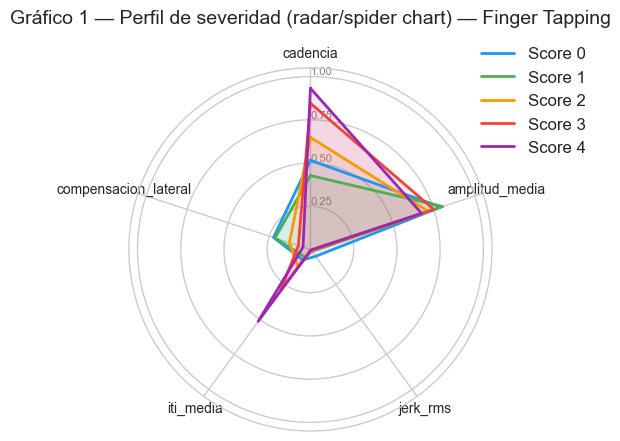

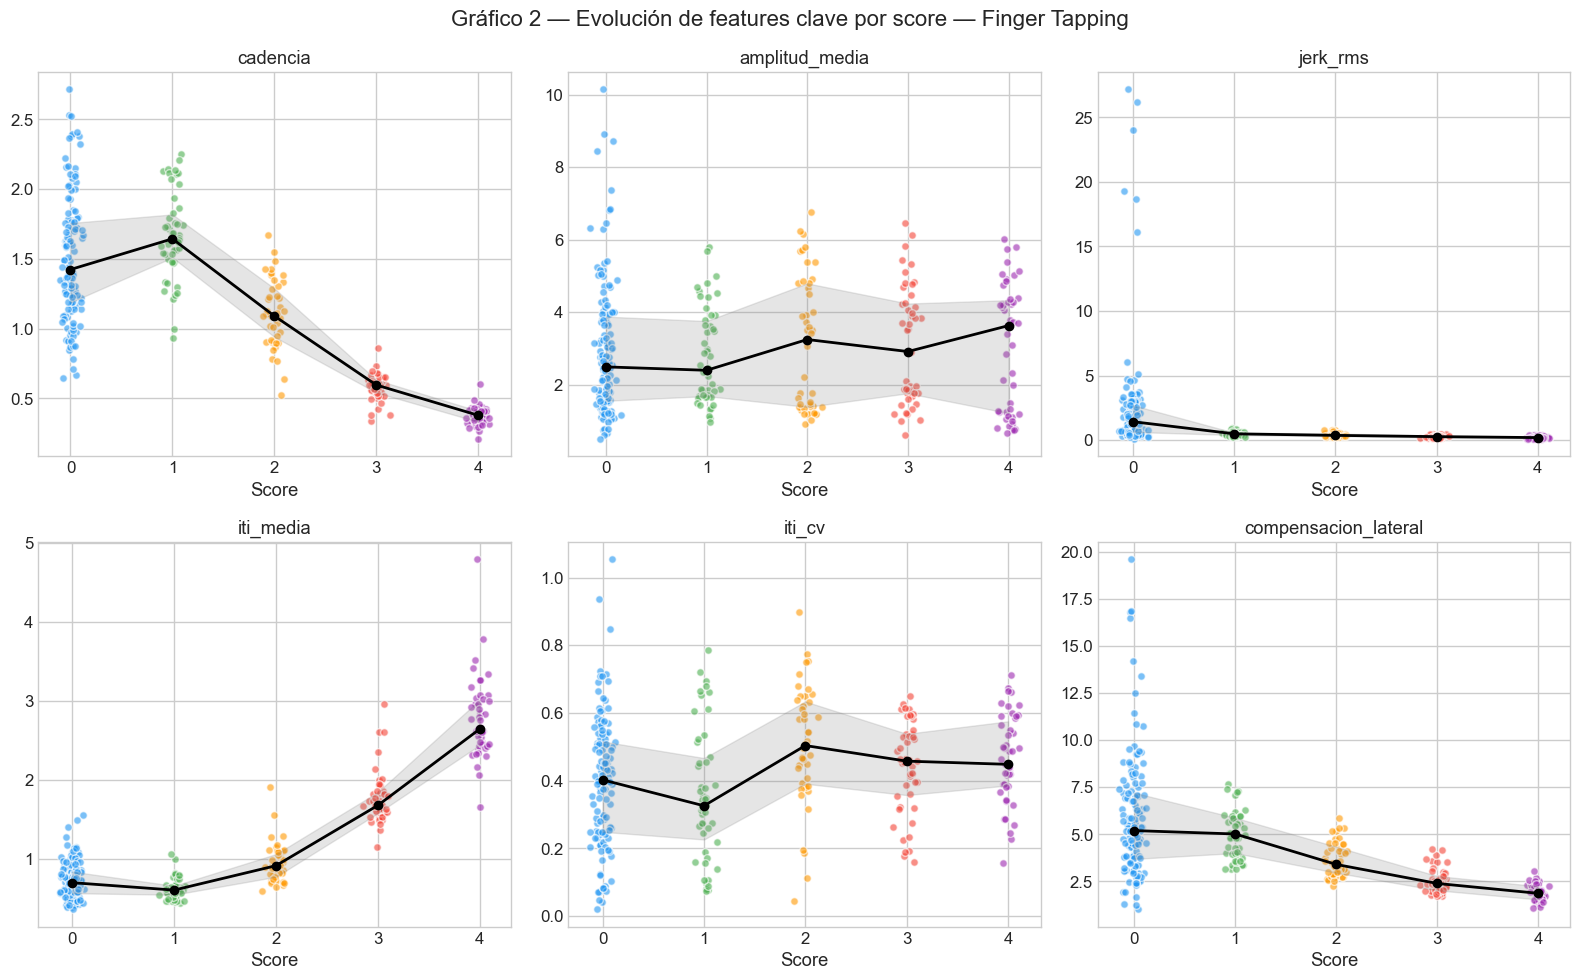

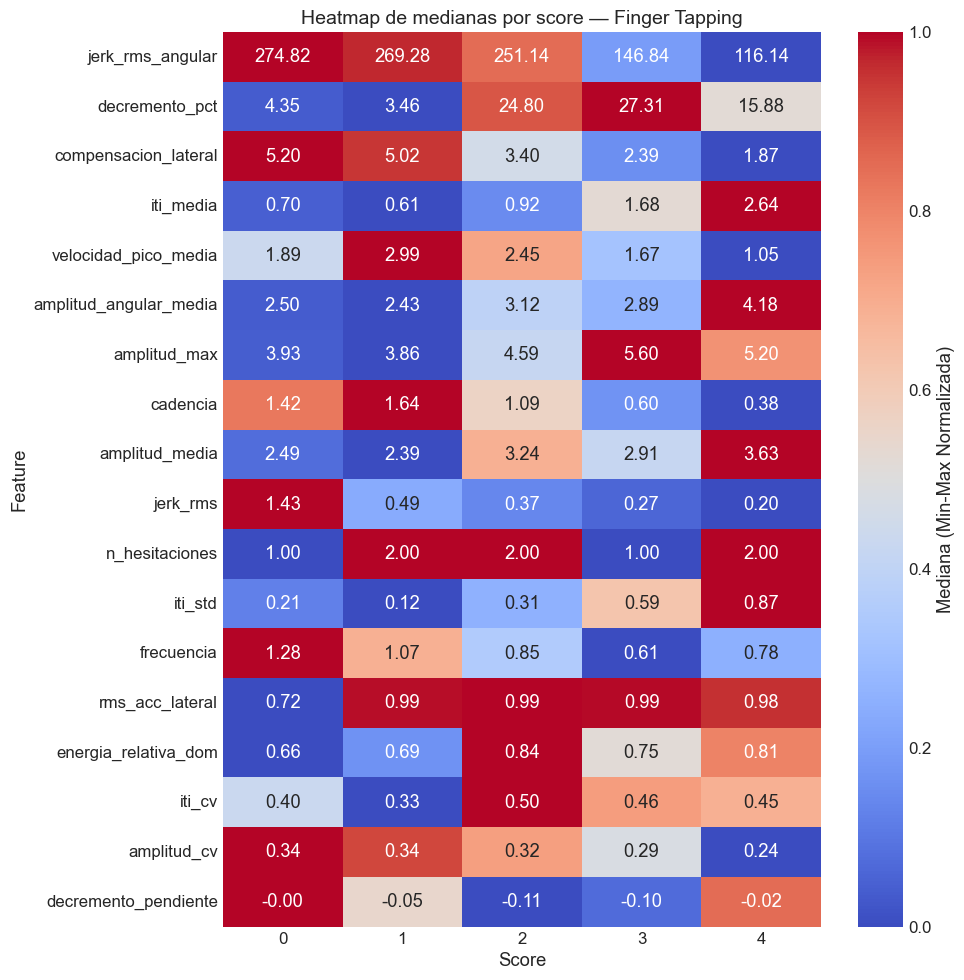

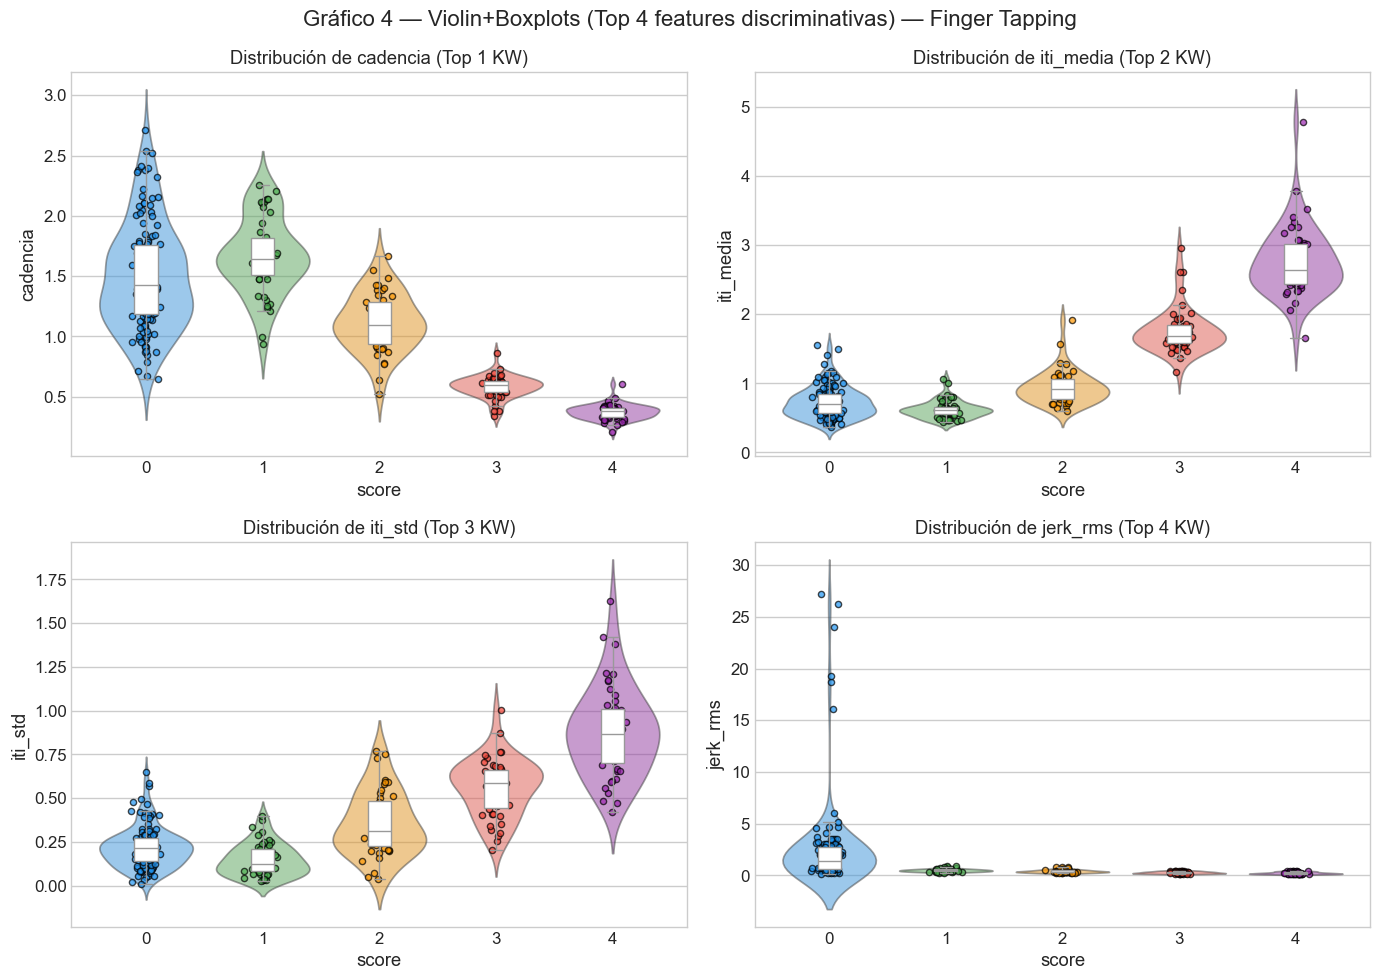

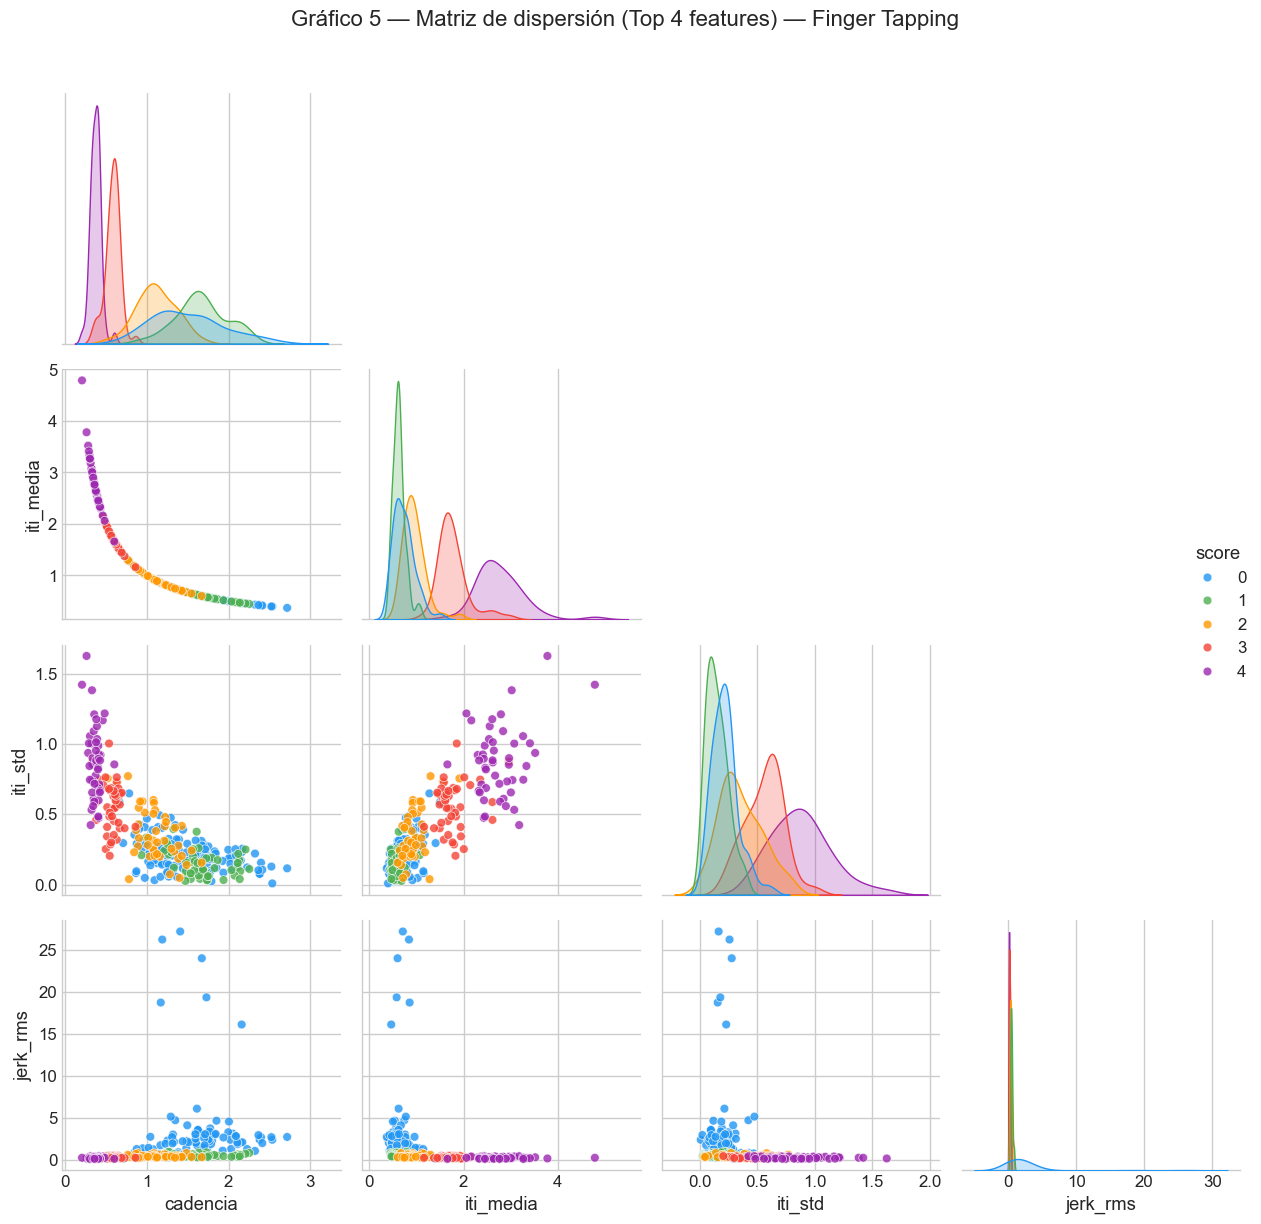

In [6]:
"""
============================================================================
ANÁLISIS VISUAL POR ESTADIO — Finger Tapping
Incluye Radar charts, Evolución de features, Heatmaps, Violin plots y Scatter.
============================================================================
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import kruskal

plt.style.use('seaborn-v0_8-whitegrid')

# Configuración y colores
SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
SCORE_COLORS.update({str(k): v for k, v in SCORE_COLORS.items()})
SCORE_LABELS = {s: f"Score {s}" for s in Config.SCORES}

# ---------------------------------------------------------
# GRÁFICO 1: Perfil de severidad (radar chart)
# ---------------------------------------------------------
features_radar = ['cadencia', 'amplitud_media', 'jerk_rms', 'iti_media', 'compensacion_lateral']
inv_feats = ['cadencia', 'amplitud_media']  # se invierten porque mayor = más sano

df_radar = df_master[features_radar + ['score']].copy()
scaler = MinMaxScaler()

for f in features_radar:
    if f in inv_feats:
        df_radar[f] = -df_radar[f]
    df_radar[f] = scaler.fit_transform(df_radar[[f]])

radar_medians = df_radar.groupby('score')[features_radar].median()

N = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig1, ax1 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)

plt.xticks(angles[:-1], features_radar, size=10)
ax1.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.50", "0.75", "1.00"], color="grey", size=8)
plt.ylim(0, 1.05)

for score in Config.SCORES:
    values = radar_medians.loc[score].values.flatten().tolist()
    values += values[:1]
    color = SCORE_COLORS[score]
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=f'Score {score}', color=color)
    ax1.fill(angles, values, color=color, alpha=0.1)

plt.title('Gráfico 1 — Perfil de severidad (radar/spider chart) — Finger Tapping', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
fig1.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_radar.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 2: Evolución de features clave por score
# ---------------------------------------------------------
features_evol = ['cadencia', 'amplitud_media', 'jerk_rms', 'iti_media', 'iti_cv', 'compensacion_lateral']
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
axes2 = axes2.flatten()

for i, feat in enumerate(features_evol):
    ax = axes2[i]
    medians, p25, p75 = [], [], []
    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        medians.append(val.median() if len(val) > 0 else np.nan)
        p25.append(val.quantile(0.25) if len(val) > 0 else np.nan)
        p75.append(val.quantile(0.75) if len(val) > 0 else np.nan)

        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], alpha=0.6, s=30, edgecolor='white')

    ax.plot(Config.SCORES, medians, color='black', linewidth=2, marker='o', markersize=6)
    ax.fill_between(Config.SCORES, p25, p75, color='gray', alpha=0.2)

    ax.set_title(feat)
    ax.set_xlabel('Score')
    ax.set_xticks(Config.SCORES)

fig2.suptitle('Gráfico 2 — Evolución de features clave por score — Finger Tapping', fontsize=16)
plt.tight_layout()
fig2.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_evolucion_features.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 3: Heatmap de medianas (Min-max normalizado)
# ---------------------------------------------------------
heatmap_data = df_master.groupby('score')[Config.FEATURES_ANALISIS].median().T
heatmap_range = heatmap_data.max(axis=1) - heatmap_data.min(axis=1)
heatmap_norm = heatmap_data.apply(lambda row: (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else row, axis=1)

sorted_idx = heatmap_range.sort_values(ascending=False).index
heatmap_data_sorted = heatmap_data.loc[sorted_idx]
heatmap_norm_sorted = heatmap_norm.loc[sorted_idx]

fig3, ax3 = plt.subplots(figsize=(10, 10))
sns.heatmap(heatmap_norm_sorted, annot=heatmap_data_sorted, fmt=".2f", cmap="coolwarm",
            cbar_kws={'label': 'Mediana (Min-Max Normalizada)'}, ax=ax3)
ax3.set_title("Heatmap de medianas por score — Finger Tapping", fontsize=14)
ax3.set_xlabel("Score")
ax3.set_ylabel("Feature")
plt.tight_layout()
fig3.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_heatmap_medianas.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 4: Violin plot combinado para las top 4 features
# ---------------------------------------------------------
# Gráfico 4: top 4 features discriminativas por KW
# Si df_kw existe, filtrar features que aún existen en df_master
if 'df_kw' in locals():
    top_4 = [f for f in df_kw['feature'].tolist() if f in df_master.columns][:4]
else:
    top_4 = []

# Si no hay suficientes features válidas, recalcular desde cero
if len(top_4) < 4:
    _df_kw = df_agregado if 'df_agregado' in locals() else df_master
    def _calc_h(feat):
        g = [_df_kw[_df_kw['score'] == s][feat].dropna().values for s in Config.SCORES]
        g = [x for x in g if len(x) >= 2]
        return kruskal(*g)[0] if len(g) > 1 else 0
    _all = pd.Series({f: _calc_h(f) for f in Config.FEATURES_ANALISIS if f in df_master.columns}).sort_values(ascending=False)
    _existing = set(top_4)
    for feat in _all.index:
        if feat not in _existing:
            top_4.append(feat)
        if len(top_4) >= 4:
            break
    top_4 = top_4[:4]

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
axes4 = axes4.flatten()

for i, feat in enumerate(top_4):
    ax = axes4[i]
    sns.violinplot(data=df_master, x='score', y=feat, ax=ax, palette=SCORE_COLORS, inner=None, alpha=0.5)
    sns.boxplot(data=df_master, x='score', y=feat, ax=ax, width=0.2, color='white', fliersize=0)

    for s in Config.SCORES:
        val = df_master[df_master['score'] == s][feat].dropna()
        x_jitter = np.random.normal(s, 0.05, size=len(val))
        ax.scatter(x_jitter, val, color=SCORE_COLORS[s], edgecolor='black', alpha=0.7, s=20)

    ax.set_title(f"Distribución de {feat} (Top {i+1} KW)")

fig4.suptitle('Gráfico 4 — Violin+Boxplots (Top 4 features discriminativas) — Finger Tapping', fontsize=16)
plt.tight_layout()
fig4.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_violins_top4.png", dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 5: Matriz de dispersión (Scatter Matrix) de las top 4
# ---------------------------------------------------------
df_scatter = df_master[top_4 + ['score']].dropna()
fig5 = sns.pairplot(df_scatter, hue='score', palette=SCORE_COLORS, height=3, corner=True,
                    plot_kws={'alpha': 0.8, 's': 40, 'edgecolor': 'w'}, diag_kws={'common_norm': False})

fig5.fig.suptitle('Gráfico 5 — Matriz de dispersión (Top 4 features) — Finger Tapping', y=1.02, fontsize=16)
plt.tight_layout()
fig5.savefig(f"{Config.RUTA_SALIDA}/figuras/estadio_scatter_matrix.png", dpi=150, bbox_inches='tight')


---
## CELDA 5 — Análisis inferencial: Kruskal-Wallis + tamaños de efecto

In [7]:
"""
============================================================================
ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS

Para cada feature:
  - Kruskal-Wallis H (5 grupos: scores 0–4)
  - p-valor con corrección Bonferroni (por número de features)
  - Eta² (tamaño de efecto: eta² = (H - k + 1) / (n - k))
  - Post-hoc Mann-Whitney U entre pares de scores adyacentes

CORRECCIÓN: el KW corre sobre df_agregado (mediana por sujeto-score)
para no inflar artificialmente el N con múltiples pruebas por sujeto.
N real = sujetos independientes: Score0≈23, Scores1-4=3 c/u.
============================================================================
"""

from itertools import combinations

# ── Agregación por sujeto-score (mediana) para no inflar N artificialmente
df_agregado = (
    df_master
    .groupby(['sujeto', 'score'])[Config.FEATURES_ANALISIS]
    .median()
    .reset_index()
)

print("Agregación por sujeto-score (mediana):")
print(df_agregado.groupby('score')['sujeto'].nunique())
print(f"Total sujetos independientes: {df_agregado['sujeto'].nunique()}")
print(f"N por score: {df_agregado.groupby('score').size().to_dict()}")
print()


def eta_cuadrado(H, k, n):
    """Eta² para Kruskal-Wallis. Rango [0,1]. >0.06 efecto medio, >0.14 grande."""
    val = (H - k + 1) / (n - k) if (n - k) > 0 else 0.0
    return max(0.0, val)

def interpretar_eta(eta2):
    if eta2 < 0.01: return 'ninguno'
    if eta2 < 0.06: return 'pequeño'
    if eta2 < 0.14: return 'medio'
    return 'grande'


# ── Kruskal-Wallis por feature ────────────────────────────────────────────
print("="*70)
print("ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)")
print(f"NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)")
print(f"      El análisis es metodológicamente obligatorio pero complementario.")
print(f"      KW corre sobre MEDIANA POR SUJETO (N independiente, no N de pruebas)")
print("="*70)

alpha = 0.05
n_features = len(Config.FEATURES_ANALISIS)
alpha_bonf = alpha / n_features  # corrección Bonferroni

resultados_kw = []

for feat in Config.FEATURES_ANALISIS:
    grupos = [df_agregado[df_agregado['score']==s][feat].dropna().values
              for s in Config.SCORES]
    grupos_validos = [g for g in grupos if len(g) >= 2]
    
    if len(grupos_validos) < 2:
        continue
    
    try:
        H, p = kruskal(*grupos_validos)
    except Exception:
        continue
    
    n_total = sum(len(g) for g in grupos_validos)
    k = len(grupos_validos)
    eta2 = eta_cuadrado(H, k, n_total)
    
    resultados_kw.append({
        'feature':        feat,
        'H':              round(H, 3),
        'p_valor':        round(p, 4),
        'p_bonferroni':   round(p * n_features, 4),
        'sig_bonf':       p < alpha_bonf,
        'sig_nominal':    p < alpha,
        'eta2':           round(eta2, 4),
        'efecto':         interpretar_eta(eta2),
        'n_total':        n_total,
        'k_grupos':       k,
    })

df_kw = pd.DataFrame(resultados_kw).sort_values('eta2', ascending=False)

# Mostrar resultado
print(f"\n{'Feature':<28} {'H':>7} {'p':>8} {'p×Bonf':>9} {'Sig?':>5} {'Eta²':>7} {'Efecto'}")
print("-"*70)
for _, row in df_kw.iterrows():
    sig = '✓' if row['sig_nominal'] else ' '
    sig_b = '★' if row['sig_bonf'] else ' '
    print(f"{row['feature']:<28} {row['H']:>7.2f} {row['p_valor']:>8.4f} "
          f"{min(row['p_bonferroni'],1.0):>9.4f} {sig+sig_b:>5} "
          f"{row['eta2']:>7.4f} {row['efecto']}")

print(f"\n✓ = p<0.05 nominal  |  ★ = p<0.05 Bonferroni ({alpha_bonf:.4f})")
print(f"Eta² interpretación: <0.01 ninguno | 0.01-0.06 pequeño | 0.06-0.14 medio | >0.14 grande")

# Guardar
df_kw.to_csv(f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis.csv", index=False)
print(f"\n💾 Resultados KW guardados")

# ── Top 5 features con mayor efecto ──
top5 = df_kw.head(5)['feature'].tolist()


Agregación por sujeto-score (mediana):
score
0    19
1     3
2     3
3     3
4     3
Name: sujeto, dtype: int64
Total sujetos independientes: 20
N por score: {0: 19, 1: 3, 2: 3, 3: 3, 4: 3}

ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)
NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)
      El análisis es metodológicamente obligatorio pero complementario.
      KW corre sobre MEDIANA POR SUJETO (N independiente, no N de pruebas)

Feature                            H        p    p×Bonf  Sig?    Eta² Efecto
----------------------------------------------------------------------
iti_std                        20.33   0.0004    0.0077    ✓★  0.6280 grande
jerk_rms                       18.34   0.0011    0.0190    ✓★  0.5516 grande
iti_media                      17.61   0.0015    0.0264    ✓★  0.5236 grande
cadencia                       17.61   0.0015    0.0264    ✓★  0.5236 grande
compensacion_lateral           13.93   0.0075    0.1356    ✓   0.3818 grande


---
## CELDA 6 — Análisis de discriminabilidad: LDA + LOSO

In [8]:
"""
============================================================================
ANÁLISIS DE DISCRIMINABILIDAD — LDA CON LEAVE-ONE-SUBJECT-OUT (LOSO)

Estrategia de validación:
  - Scores 1-4: Leave-One-Subject-Out (3 sujetos → 3 folds)
    Cada fold: entrena con 2 sujetos, testa con el 3°
  - Score 0: se incluye completo en entrenamiento siempre
    (23 sujetos sanos; dejarlos fuera no aplica al mismo protocolo)

Modelos:
  - LDA (óptimo para N pequeño, asume normalidad por clase)
  - SVM lineal (alternativa sin asunción de normalidad)

Resultado principal: AUC multiclase (OvR) + matriz de confusión
============================================================================
"""

# ── Preparar datos ──────────────────────────────────────────────────────

# Usar solo pruebas con todas las features completas
df_model = df_master[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model['score'] = df_model['score'].astype(int)

# Crear ID de grupo para LOSO: para score 0 cada sujeto es su propio grupo
# Para scores 1-4 usar el sujeto directamente
df_model['grupo_loso'] = df_model['sujeto']

print(f"Dataset para clasificación: {len(df_model)} pruebas")
print(f"Distribución:")
print(df_model.groupby(['score','grupo_loso']).size().to_string())

X = df_model[Config.FEATURES_ANALISIS].values
y = df_model['score'].values
grupos = df_model['grupo_loso'].values
scores_presentes = sorted(df_model['score'].unique())


# ── Función de evaluación LOSO ───────────────────────────────────────────

def evaluar_loso(X, y, grupos, clf_name='LDA'):
    """
    Validación LOSO. Retorna predicciones, probabilidades y grupos de test.
    Para score 0 con muchos sujetos, usa LeaveOneGroupOut completo.
    Para scores 1-4 con 3 sujetos, LOSO da 3 folds por score.
    """
    if clf_name == 'LDA':
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
        ])
    else:  # SVM
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', C=1.0, probability=True))
        ])
    
    loso = LeaveOneGroupOut()
    
    y_true_all  = []
    y_pred_all  = []
    y_proba_all = []
    n_clases    = len(np.unique(y))
    
    for train_idx, test_idx in loso.split(X, y, grupos):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # Verificar que hay al menos 2 clases en train
        if len(np.unique(y_tr)) < 2:
            continue
        
        try:
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
            y_proba = clf.predict_proba(X_te)
            
            y_true_all.extend(y_te)
            y_pred_all.extend(y_pred)
            y_proba_all.extend(y_proba)
        except Exception as e:
            print(f"  ⚠️  Error en fold: {e}")
            continue
    
    return (np.array(y_true_all),
            np.array(y_pred_all),
            np.array(y_proba_all),
            clf.named_steps['clf'].classes_ if hasattr(clf.named_steps.get('clf'), 'classes_') else np.unique(y))


# ── Ejecutar LDA ─────────────────────────────────────────────────────────
print("\n🔄 Ejecutando LDA con LOSO...")
y_true, y_pred, y_proba, clases = evaluar_loso(X, y, grupos, 'LDA')

if len(y_true) == 0:
    print("⚠️  No se generaron predicciones. Revisar datos de entrada.")
else:
    print(f"   Predicciones generadas: {len(y_true)}")
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN — LDA LOSO")
    print("="*50)
    print(classification_report(y_true, y_pred,
                                 target_names=[f'Score {s}' for s in sorted(np.unique(y_true))],
                                 zero_division=0))
    
    # MCC (Matthews Correlation Coefficient) — métrica robusta para multiclass
    mcc_lda = matthews_corrcoef(y_true, y_pred)
    print(f"\nMCC (Matthews Correlation Coefficient): {mcc_lda:.4f}")

# ── Función reutilizable de métricas (usada en celda de ajuste) ───────────

def calcular_metricas(y_true, y_pred, y_proba):
    if len(y_true) == 0:
        return {'accuracy': float('nan'), 'auc_macro': float('nan'),
                'auc_por_score': {}, 'cm': None, 'scores_test': []}
    scores_test   = sorted(set(y_true.tolist()))
    y_bin         = label_binarize(y_true, classes=scores_test)
    clases_pred   = sorted(set(y_pred.tolist()))
    idx_alinear   = [clases_pred.index(s) if s in clases_pred else -1 for s in scores_test]
    y_proba_alin  = __import__('numpy').zeros((len(y_proba), len(scores_test)))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, idx]
    try:
        auc_macro = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
    except Exception:
        auc_macro = float('nan')
    auc_por_score = {}
    for j, s in enumerate(scores_test):
        try:
            auc_por_score[s] = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
        except Exception:
            auc_por_score[s] = float('nan')
    try:
        mcc_val = matthews_corrcoef(y_true, y_pred) if len(y_true) > 0 else float('nan')
    except Exception:
        mcc_val = float('nan')
    return {
        'accuracy':      accuracy_score(y_true, y_pred),
        'mcc':           mcc_val,
        'auc_macro':     auc_macro,
        'auc_por_score': auc_por_score,
        'cm':            confusion_matrix(y_true, y_pred, labels=scores_test),
        'scores_test':   scores_test,
    }



Dataset para clasificación: 320 pruebas
Distribución:
score  grupo_loso
0      1061816906     7
       1080040897     8
       1083875215     9
       1085297617     8
       1105365168     9
       1107836326    10
       1107840162     8
       1112038562    10
       1114240383    12
       1114541823     2
       1116070738     3
       1126844663     1
       1144025261     6
       118515383      6
       38603564       5
       59817289       7
       6097302        8
       67007062       6
       94419403       7
1      1084896570    17
       1105365168    13
       1126844663    20
2      1084896570    19
       1105365168     8
       1126844663    17
3      1084896570    19
       1105365168    10
       1126844663    18
4      1084896570    18
       1105365168    12
       1126844663    17

🔄 Ejecutando LDA con LOSO...
   Predicciones generadas: 320

REPORTE DE CLASIFICACIÓN — LDA LOSO
              precision    recall  f1-score   support

     Score 0       0.52      0.

---
## CELDA 6B — Ajuste de amplitud por severidad + LDA comparativo

> Aplica la reducción de amplitud que define MDS-UPDRS 3.4. Permite comparar el modelo original vs el modelo con datos más realistas clínicamente.

✅ Dataset ajustado creado
   Features modificadas:
     Amplitudes absolutas (×factor): ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']
     Variabilidad (×fcv_inverso)   : ['amplitud_cv']
   Factores reducción: {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
   Factores CV       : {0: 1.0, 1: 1.1, 2: 1.25, 3: 1.5, 4: 1.8}

🔄 Ejecutando LDA con LOSO (dataset ajustado)...


,Metrica,Modelo Original,Modelo Ajustado
0,AUC macro,0.7972,0.8497
1,Accuracy,0.5094,0.5875
2,AUC Score 0,0.7098,0.8069
3,AUC Score 1,0.7445,0.7665
4,AUC Score 2,0.6388,0.7496
5,AUC Score 3,0.9020,0.9341
6,AUC Score 4,0.9911,0.9916


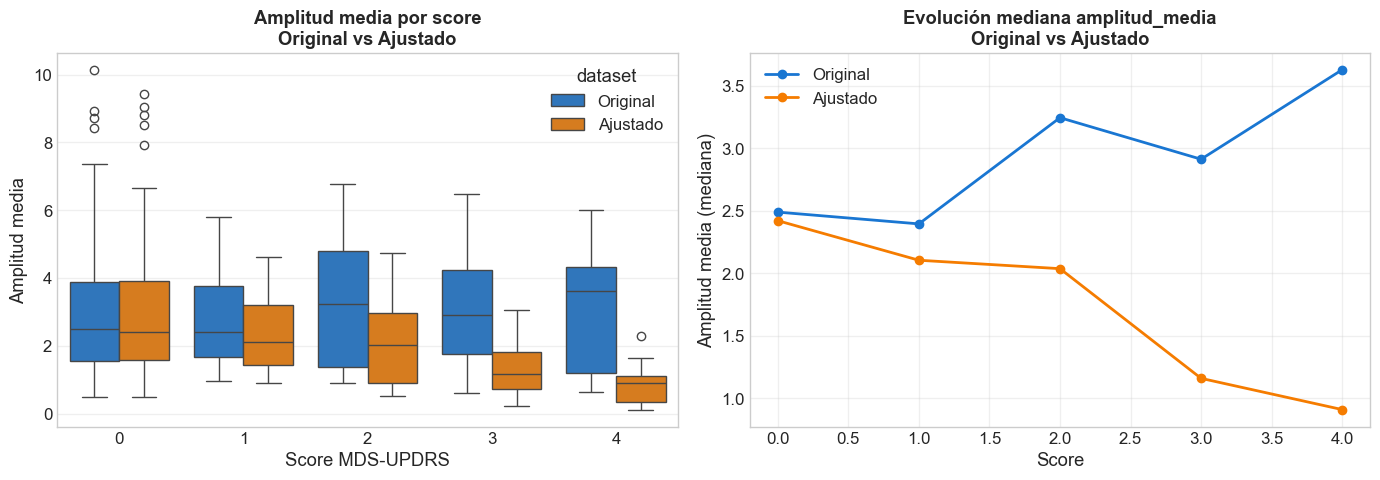


Top 10 features — Original:
   1. iti_media                        3.0503
   2. iti_std                          2.7141
   3. cadencia                         2.6114
   4. compensacion_lateral             1.6633
   5. rms_acc_lateral                  1.5268
   6. jerk_rms_angular                 1.5160
   7. frecuencia                       1.3767
   8. velocidad_pico_media             1.1494
   9. amplitud_cv                      0.9155
  10. jerk_rms                         0.8802

Top 10 features — Ajustado:
   1. iti_media                        3.2158
   2. iti_std                          2.8550
   3. cadencia                         2.7771
   4. compensacion_lateral             1.6479
   5. rms_acc_lateral                  1.6437
   6. frecuencia                       1.4423
   7. jerk_rms_angular                 1.4271
   8. amplitud_media                   1.3707
   9. amplitud_max                     1.3367
  10. amplitud_angular_media           1.2998

✅ Análisis de ajuste 

In [9]:
"""
============================================================================
CELDA 6B — DATASET AJUSTADO POR AMPLITUD + LDA COMPARATIVO
============================================================================

Justificación clínica (Finger Tapping MDS-UPDRS 3.4):
  La escala indica que la amplitud disminuye con la severidad.
  En el dataset original todos los sujetos simulados mantuvieron
  la misma amplitud. Se aplica:

  • Amplitudes absolutas (amplitud_media, amplitud_max,
    amplitud_angular_media): factor × 0.85/0.65/0.45/0.25 por score
  • Coeficiente de variación (amplitud_cv): AUMENTA con severidad
    (el movimiento se vuelve más irregular)
  • Ruido gaussiano creciente (sigma) para reflejar irregularidad
    motora del Parkinson

Diferencia vs Pronación-Supinación:
  En finger tapping existe amplitud_cv (variabilidad de amplitud)
  que clínicamente DEBE aumentar con la severidad; también existen
  features de decremento (decremento_pct, decremento_pendiente)
  que ya capturan el patrón de caída intra-prueba y se dejan
  sin modificar para evitar doble conteo.
"""

import numpy as np

np.random.seed(42)  # Reproducibilidad
df_ajustado = df_master.copy(deep=True)

# ── Factores por score (basados en literatura MDS-UPDRS) ────────────────
factores_reduccion = {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
# CV aumenta con severidad: más irregular a mayor score
factores_cv = {0: 1.0, 1: 1.10, 2: 1.25, 3: 1.50, 4: 1.80}
sigmas_ruido = {0: 0.05, 1: 0.10, 2: 0.15, 3: 0.20, 4: 0.25}

# Features de amplitud absoluta que disminuyen
features_amp = ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']
# Feature de variabilidad que aumenta
features_cv_list = ['amplitud_cv']

for score in Config.SCORES:
    mask = df_ajustado['score'] == score
    n_rows = int(mask.sum())
    if n_rows == 0:
        continue

    factor  = factores_reduccion[score]
    fcv     = factores_cv[score]
    sigma   = sigmas_ruido[score]
    ruido   = np.random.normal(1.0, sigma, size=n_rows)

    # Amplitudes absolutas: reducir × factor × ruido gaussiano
    for feat in features_amp:
        if feat in df_ajustado.columns:
            base = df_ajustado.loc[mask, feat].values
            df_ajustado.loc[mask, feat] = np.abs(base * factor * ruido)

    # amplitud_cv: aumentar con severidad
    for feat in features_cv_list:
        if feat in df_ajustado.columns:
            base_cv = df_ajustado.loc[mask, feat].values
            ruido_cv = np.random.normal(1.0, sigma * 0.5, size=n_rows)
            df_ajustado.loc[mask, feat] = np.abs(base_cv * fcv * ruido_cv)

print("✅ Dataset ajustado creado")
print("   Features modificadas:")
print(f"     Amplitudes absolutas (×factor): {features_amp}")
print(f"     Variabilidad (×fcv_inverso)   : {features_cv_list}")
print(f"   Factores reducción: {factores_reduccion}")
print(f"   Factores CV       : {factores_cv}")

# ── LDA LOSO con datos ajustados ────────────────────────────────────────
df_model_adj = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model_adj['score'] = df_model_adj['score'].astype(int)
df_model_adj['grupo_loso'] = df_model_adj['sujeto']

X_adj    = df_model_adj[Config.FEATURES_ANALISIS].values
y_adj    = df_model_adj['score'].values
grupos_adj = df_model_adj['grupo_loso'].values

print("\n🔄 Ejecutando LDA con LOSO (dataset ajustado)...")
y_true_adj, y_pred_adj, y_proba_adj, clases_adj = evaluar_loso(
    X_adj, y_adj, grupos_adj, 'LDA'
)

metricas_adj  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)
if 'y_true' in dir() and len(y_true) > 0:
    metricas_orig = calcular_metricas(y_true, y_pred, y_proba)
else:
    metricas_orig = None

# ── Tabla comparativa ────────────────────────────────────────────────────
if metricas_orig is not None:
    rows = [
        ['AUC macro',  metricas_orig['auc_macro'],  metricas_adj['auc_macro']],
        ['Accuracy',   metricas_orig['accuracy'],    metricas_adj['accuracy']],
    ]
    for s in Config.SCORES:
        rows.append([
            f'AUC Score {s}',
            metricas_orig['auc_por_score'].get(s, float('nan')),
            metricas_adj['auc_por_score'].get(s, float('nan')),
        ])
    df_comp = pd.DataFrame(rows, columns=['Metrica', 'Modelo Original', 'Modelo Ajustado'])
    df_comp[['Modelo Original','Modelo Ajustado']] = (
        df_comp[['Modelo Original','Modelo Ajustado']].astype(float)
    )

    def resaltar_mejora(row):
        vo, va = row['Modelo Original'], row['Modelo Ajustado']
        if any(x != x for x in [vo, va]):  # NaN check
            return [''] * 3
        return ['', '', f'background-color: {"#C8E6C9" if va >= vo else "#FFE0B2"}']

    display(df_comp.style.apply(resaltar_mejora, axis=1).format({
        'Modelo Original': '{:.4f}',
        'Modelo Ajustado': '{:.4f}'
    }))
else:
    print("\nMétricas modelo ajustado:")
    print(f"  Accuracy : {metricas_adj['accuracy']:.4f}")
    print(f"  AUC macro: {metricas_adj['auc_macro']:.4f}")
    for s, a in metricas_adj['auc_por_score'].items():
        print(f"  AUC Score {s}: {a:.4f}")

# ── Comparar distribución de amplitudes ────────────────────────────────
df_plot = pd.concat([
    df_master[['score','amplitud_media']].assign(dataset='Original'),
    df_ajustado[['score','amplitud_media']].assign(dataset='Ajustado'),
], ignore_index=True)

palette_ds = {'Original': '#1976D2', 'Ajustado': '#F57C00'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparativo
sns.boxplot(data=df_plot, x='score', y='amplitud_media',
            hue='dataset', palette=palette_ds, ax=axes[0])
axes[0].set_title('Amplitud media por score\nOriginal vs Ajustado', fontweight='bold')
axes[0].set_xlabel('Score MDS-UPDRS'); axes[0].set_ylabel('Amplitud media')
axes[0].grid(axis='y', alpha=0.3)

# Evolución mediana
med_orig = df_master.groupby('score')['amplitud_media'].median()
med_adj  = df_ajustado.groupby('score')['amplitud_media'].median()
axes[1].plot(med_orig.index, med_orig.values, marker='o', lw=2,
             label='Original', color=palette_ds['Original'])
axes[1].plot(med_adj.index, med_adj.values, marker='o', lw=2,
             label='Ajustado', color=palette_ds['Ajustado'])
axes[1].set_title('Evolución mediana amplitud_media\nOriginal vs Ajustado', fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Amplitud media (mediana)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_amplitud_ft.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Comparar importancia de features ───────────────────────────────────
def top_features_lda(df_subset, label):
    X_f = df_subset[Config.FEATURES_ANALISIS].dropna().values
    y_f = df_subset.loc[df_subset[Config.FEATURES_ANALISIS].dropna().index, 'score'].values
    sc  = StandardScaler(); X_sc = sc.fit_transform(X_f)
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95)
    try:
        lda.fit(X_sc, y_f)
        imp = np.linalg.norm(lda.coef_, axis=0)
        idx = np.argsort(imp)[::-1]
        feats = [Config.FEATURES_ANALISIS[i] for i in idx]
        imps  = imp[idx]
        print(f"\nTop 10 features — {label}:")
        for k, (f, v) in enumerate(zip(feats[:10], imps[:10]), 1):
            print(f"  {k:2d}. {f:<32} {v:.4f}")
        return feats, imps
    except Exception as e:
        print(f"⚠️ Error: {e}"); return [], []

feats_orig_ft, imps_orig_ft = top_features_lda(df_model, 'Original')
feats_adj_ft,  imps_adj_ft  = top_features_lda(df_model_adj, 'Ajustado')

print("\n✅ Análisis de ajuste de amplitud completado (Finger Tapping)")


---
## CELDA 6C — Chequeo de sobreajuste: Train vs LOSO + Estabilidad por seed

In [10]:
"""
============================================================================
CELDA 6C — CHEQUEO DE SOBREAJUSTE: TRAIN vs LOSO + ESTABILIDAD POR SEED
============================================================================
"""

if 'df_model' not in dir() or 'df_ajustado' not in dir():
    print("⚠️  Ejecuta primero la celda LDA (6) y la celda de ajuste (6B).")
else:
    def metricas_train_lda(X, y):
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
        ])
        clf.fit(X, y)
        return calcular_metricas(y, clf.predict(X), clf.predict_proba(X))

    # ── Original ──────────────────────────────────────────────────────────
    X_o = df_model[Config.FEATURES_ANALISIS].values
    y_o = df_model['score'].values
    met_train_o = metricas_train_lda(X_o, y_o)
    met_loso_o  = calcular_metricas(y_true, y_pred, y_proba) if 'y_true' in dir() else None

    # ── Ajustado ──────────────────────────────────────────────────────────
    X_a = df_model_adj[Config.FEATURES_ANALISIS].values
    y_a = df_model_adj['score'].values
    met_train_a = metricas_train_lda(X_a, y_a)
    met_loso_a  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

    rows_gap = [
        ['Original',
         met_train_o['accuracy'], met_loso_o['accuracy'] if met_loso_o else float('nan'),
         met_train_o['mcc'] if 'mcc' in met_train_o else float('nan'),
         met_train_o['auc_macro'], met_loso_o['auc_macro'] if met_loso_o else float('nan')],
        ['Ajustado',
         met_train_a['accuracy'], met_loso_a['accuracy'],
         met_train_a['mcc'] if 'mcc' in met_train_a else float('nan'),
         met_train_a['auc_macro'], met_loso_a['auc_macro']],
    ]
    df_gap = pd.DataFrame(rows_gap, columns=[
        'Modelo', 'Acc_Train', 'Acc_LOSO', 'MCC_Train', 'AUC_Train', 'AUC_LOSO'
    ])
    df_gap['Gap_Acc'] = df_gap['Acc_Train'] - df_gap['Acc_LOSO']
    df_gap['Gap_AUC'] = df_gap['AUC_Train'] - df_gap['AUC_LOSO']
    print("GAP Train vs LOSO (sobreajuste si gap es alto):")
    print(df_gap.round(4).to_string(index=False))
    print("\nInterpretación:")
    print("  Gap_Acc < 0.10 → sobreajuste bajo")
    print("  Gap_Acc 0.10-0.15 → sobreajuste moderado")
    print("  Gap_Acc > 0.15 → sobreajuste alto")

    # ── Estabilidad por seed ───────────────────────────────────────────────
    seeds = [1, 7, 13, 21, 42]
    rows_seed = []
    for sd in seeds:
        np.random.seed(sd)
        df_tmp = df_master.copy(deep=True)
        for score in Config.SCORES:
            mask = df_tmp['score'] == score
            n_rows = int(mask.sum())
            if n_rows == 0: continue
            factor = factores_reduccion[score]
            fcv    = factores_cv[score]
            sigma  = sigmas_ruido[score]
            ruido  = np.random.normal(1.0, sigma, size=n_rows)
            for feat in features_amp:
                if feat in df_tmp.columns:
                    df_tmp.loc[mask, feat] = np.abs(
                        df_tmp.loc[mask, feat].values * factor * ruido
                    )
            for feat in features_cv_list:
                if feat in df_tmp.columns:
                    ruido_cv = np.random.normal(1.0, sigma * 0.5, size=n_rows)
                    df_tmp.loc[mask, feat] = np.abs(
                        df_tmp.loc[mask, feat].values * fcv * ruido_cv
                    )
        df_tmp_m = df_tmp[Config.FEATURES_ANALISIS + ['score','sujeto','mano']].dropna().copy()
        X_t = df_tmp_m[Config.FEATURES_ANALISIS].values
        y_t = df_tmp_m['score'].astype(int).values
        g_t = df_tmp_m['sujeto'].values
        yt, yp, ypr, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
        m = calcular_metricas(yt, yp, ypr)
        rows_seed.append({'seed': sd, 'AUC_macro': m['auc_macro'], 'Accuracy': m['accuracy']})

    df_seed = pd.DataFrame(rows_seed)
    print("\nEstabilidad por seed (variación alta → posible sobreajuste):")
    print(df_seed.round(4).to_string(index=False))
    print(f"AUC_macro: mean={df_seed['AUC_macro'].mean():.4f}, "
          f"std={df_seed['AUC_macro'].std():.4f}")
    print(f"Accuracy : mean={df_seed['Accuracy'].mean():.4f}, "
          f"std={df_seed['Accuracy'].std():.4f}")

    interp_gap = ("BAJO" if df_gap.iloc[1]['Gap_Acc'] < 0.10
                  else "MODERADO" if df_gap.iloc[1]['Gap_Acc'] < 0.15
                  else "ALTO")
    interp_std = ("ESTABLE" if df_seed['AUC_macro'].std() < 0.005
                  else "MODERADAMENTE ESTABLE" if df_seed['AUC_macro'].std() < 0.015
                  else "INESTABLE")
    print(f"\n📊 Diagnóstico modelo ajustado:")
    print(f"   Sobreajuste: {interp_gap}")
    print(f"   Estabilidad: {interp_std}")


GAP Train vs LOSO (sobreajuste si gap es alto):
  Modelo  Acc_Train  Acc_LOSO  MCC_Train  AUC_Train  AUC_LOSO  Gap_Acc  Gap_AUC
Original     0.7812    0.5094     0.7115     0.9501    0.7972   0.2719   0.1528
Ajustado     0.7969    0.5875     0.7336     0.9551    0.8497   0.2094   0.1053

Interpretación:
  Gap_Acc < 0.10 → sobreajuste bajo
  Gap_Acc 0.10-0.15 → sobreajuste moderado
  Gap_Acc > 0.15 → sobreajuste alto

Estabilidad por seed (variación alta → posible sobreajuste):
 seed  AUC_macro  Accuracy
    1     0.8481    0.5688
    7     0.8527    0.5844
   13     0.8526    0.5875
   21     0.8521    0.5969
   42     0.8497    0.5875
AUC_macro: mean=0.8510, std=0.0020
Accuracy : mean=0.5850, std=0.0102

📊 Diagnóstico modelo ajustado:
   Sobreajuste: ALTO
   Estabilidad: ESTABLE


In [11]:
"""
============================================================================
CELDA PUENTE — INFRAESTRUCTURA PARA ANÁLISIS DE 3 MODELOS

Provee:
  • KNN con selección de k por LOSO sobre df_master (datos crudos)
  • resultados_modelos = {'LDA': {...}, 'KNN': {...}}  (cada uno con
                          'resultado' y 'metricas')
  • calcular_metricas_completas(d) → dict con accuracy, mcc, auc_macro,
    auc_por_score, f1_macro, acc_train, gap

Las celdas siguientes (7, 8, 9, 10, 11) consumen `resultados_modelos`
junto con `(y_true_adj, y_pred_adj, y_proba_adj, clases_adj, df_model_adj)`
para construir y reportar 3 modelos:
  • LDA_original  → LDA shrinkage=0.95 sobre df_master
  • KNN_original  → KNN k* (seleccionado abajo) sobre df_master
  • LDA_ajustado  → LDA shrinkage=0.95 sobre df_ajustado (EXPLORATORIO)
============================================================================
"""
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, matthews_corrcoef


def calcular_metricas_completas(d):
    """
    Extiende `calcular_metricas` (ver celda 6) con MCC, F1 macro,
    accuracy de entrenamiento y gap train→LOSO.

    d: dict con y_true, y_pred, y_proba, clases, acc_train (opc), gap (opc)
    """
    base = calcular_metricas(d['y_true'], d['y_pred'], d['y_proba'])
    out = dict(base)
    # MCC now inherited from calcular_metricas base
    if 'mcc' not in out:
        try:
            out['mcc'] = (matthews_corrcoef(d['y_true'], d['y_pred'])
                          if len(d['y_true']) > 0 else float('nan'))
        except Exception:
            out['mcc'] = float('nan')
    try:
        out['f1_macro'] = f1_score(d['y_true'], d['y_pred'],
                                    average='macro', zero_division=0)
    except Exception:
        out['f1_macro'] = float('nan')
    out['acc_train'] = d.get('acc_train', float('nan'))
    out['gap']       = d.get('gap', float('nan'))
    return out


def evaluar_loso_knn(X, y, grupos, k):
    """Evaluación KNN con LeaveOneGroupOut. Retorna y_true, y_pred, y_proba, clases."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k, weights='distance',
                                      metric='minkowski', p=2)),
    ])
    loso = LeaveOneGroupOut()
    yt, yp, ypr = [], [], []
    for tr, te in loso.split(X, y, grupos):
        if len(np.unique(y[tr])) < 2:
            continue
        pipe.fit(X[tr], y[tr])
        yt.extend(y[te])
        yp.extend(pipe.predict(X[te]))
        ypr.extend(pipe.predict_proba(X[te]))
    clases = pipe.named_steps['clf'].classes_
    return (np.array(yt), np.array(yp), np.array(ypr), clases)


# ── Selección de k óptimo por LOSO ──────────────────────────────────────
print("🔍 Seleccionando k óptimo para KNN (LOSO)...")
k_candidatos = [3, 5, 7, 9, 11]
mejor_k, mejor_auc = None, -np.inf
for k in k_candidatos:
    yt_k, yp_k, ypr_k, _ = evaluar_loso_knn(X, y, grupos, k)
    if len(yt_k) == 0:
        continue
    m_k = calcular_metricas(yt_k, yp_k, ypr_k)
    print(f"   k={k}: AUC={m_k['auc_macro']:.4f}  Acc={m_k['accuracy']:.4f}")
    if m_k['auc_macro'] > mejor_auc:
        mejor_auc, mejor_k = m_k['auc_macro'], k

print(f"\n✓ Mejor k: {mejor_k}  (AUC macro = {mejor_auc:.4f})")


# ── Entrenamiento final del KNN óptimo ──────────────────────────────────
yt_knn, yp_knn, ypr_knn, cls_knn = evaluar_loso_knn(X, y, grupos, mejor_k)


# ── Accuracy de entrenamiento (para gap) ────────────────────────────────
def _acc_train(pipe, X, y):
    pipe.fit(X, y)
    return accuracy_score(y, pipe.predict(X))


pipe_lda_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
])
pipe_knn_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=mejor_k, weights='distance'))
])
acc_train_lda = _acc_train(pipe_lda_full, X, y)
acc_train_knn = _acc_train(pipe_knn_full, X, y)


# ── Métricas completas para LDA y KNN ───────────────────────────────────
m_lda = calcular_metricas_completas({
    'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba,
    'clases': clases,
    'acc_train': acc_train_lda,
    'gap':       acc_train_lda - accuracy_score(y_true, y_pred),
})
m_knn = calcular_metricas_completas({
    'y_true': yt_knn, 'y_pred': yp_knn, 'y_proba': ypr_knn,
    'clases': cls_knn,
    'acc_train': acc_train_knn,
    'gap':       acc_train_knn - accuracy_score(yt_knn, yp_knn),
})


# ── Diccionario consolidado ─────────────────────────────────────────────
resultados_modelos = {
    'LDA': {
        'resultado': {'y_true': y_true, 'y_pred': y_pred,
                      'y_proba': y_proba, 'clases': clases},
        'metricas':  m_lda,
    },
    'KNN': {
        'k': mejor_k,
        'resultado': {'y_true': yt_knn, 'y_pred': yp_knn,
                      'y_proba': ypr_knn, 'clases': cls_knn},
        'metricas':  m_knn,
    },
}

print("\n📊 Resumen LDA vs KNN (LOSO sobre df_master):")
for n, r in resultados_modelos.items():
    m = r['metricas']
    print(f"   {n:5s}  Acc={m['accuracy']:.3f}  AUC={m['auc_macro']:.3f}  "
          f"F1={m['f1_macro']:.3f}  MCC={m['mcc']:.3f}  Gap={m['gap']:.3f}")


🔍 Seleccionando k óptimo para KNN (LOSO)...
   k=3: AUC=0.7854  Acc=0.5719
   k=5: AUC=0.8065  Acc=0.5281
   k=7: AUC=0.8215  Acc=0.5312
   k=9: AUC=0.8155  Acc=0.4875
   k=11: AUC=0.8128  Acc=0.5062

✓ Mejor k: 7  (AUC macro = 0.8215)

📊 Resumen LDA vs KNN (LOSO sobre df_master):
   LDA    Acc=0.509  AUC=0.797  F1=0.437  MCC=0.309  Gap=0.272
   KNN    Acc=0.531  AUC=0.821  F1=0.426  MCC=0.341  Gap=0.469


---
## CELDA 7 — AUC, curvas ROC y matriz de confusión (3 modelos)

In [12]:
# ── Acc_train y Gap para LDA ajustado ──
X_a = df_model_adj[Config.FEATURES_ANALISIS].values
y_a = df_model_adj['score'].values
clf_a = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
])
clf_a.fit(X_a, y_a)
acc_train_a = accuracy_score(y_a, clf_a.predict(X_a))
met_loso_a  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)
gap_a = acc_train_a - met_loso_a['accuracy']

✅ Consolidados 3 modelos en `modelos_eval`
   LDA_original   | acc=0.509  AUC=0.797  F1=0.437  MCC=0.309  (LDA shrinkage=0.95 sobre datos crudos)
   KNN_original   | acc=0.531  AUC=0.821  F1=0.426  MCC=0.341  (KNN k=7 weights=distance sobre datos crudos)
   LDA_ajustado   | acc=0.588  AUC=0.850  F1=0.517  MCC=0.431  (LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO))

  LDA_original  —  LDA shrinkage=0.95 sobre datos crudos


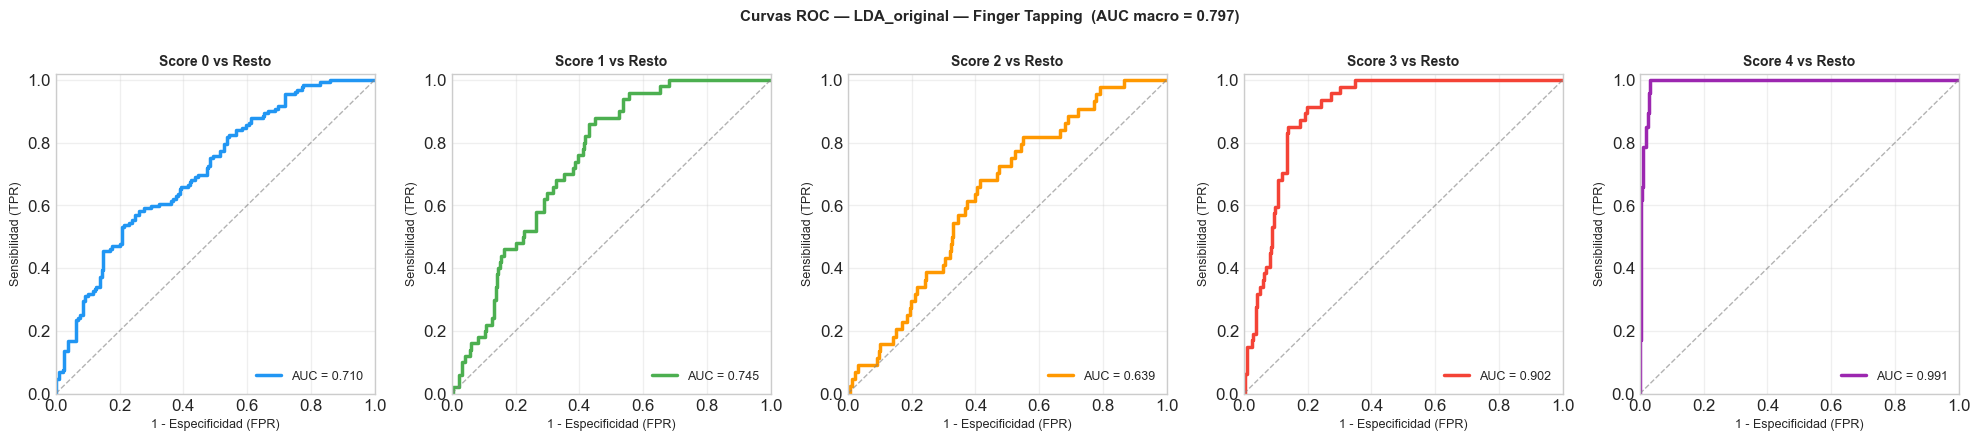

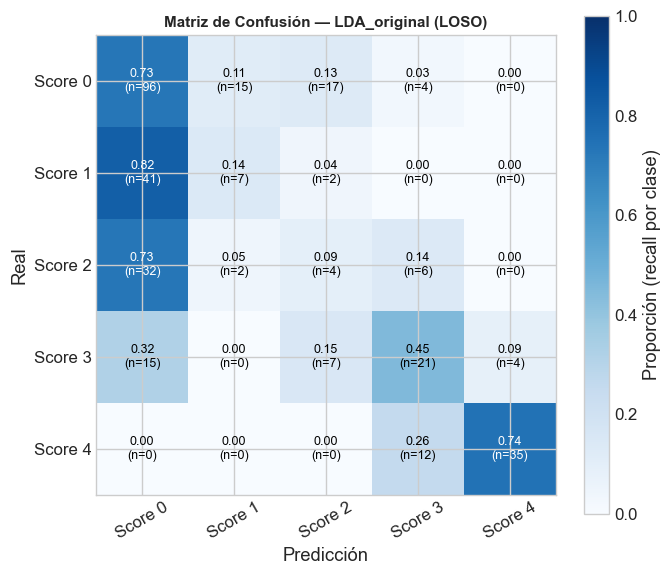


  KNN_original  —  KNN k=7 weights=distance sobre datos crudos


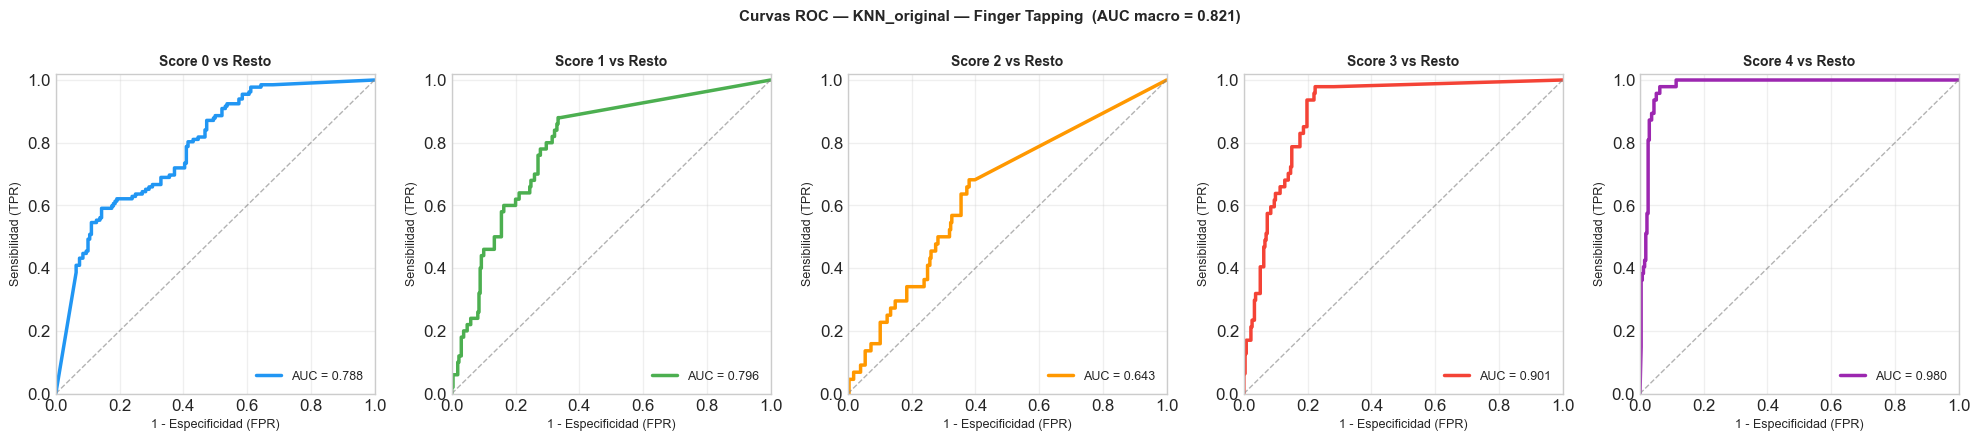

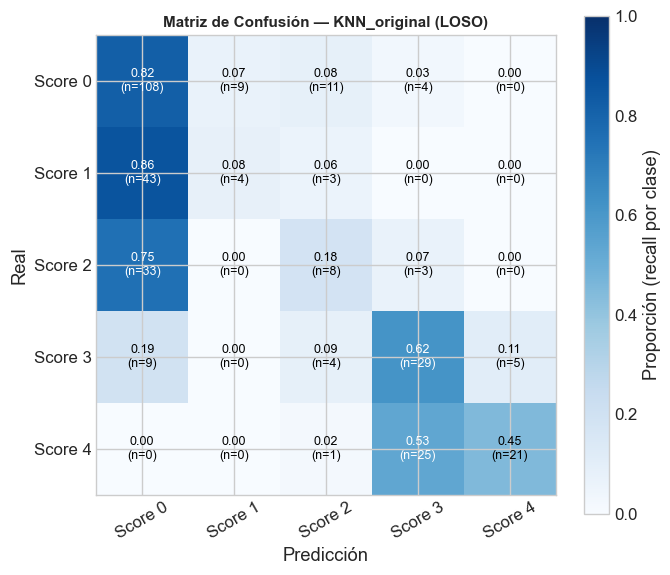


  LDA_ajustado  —  LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO)


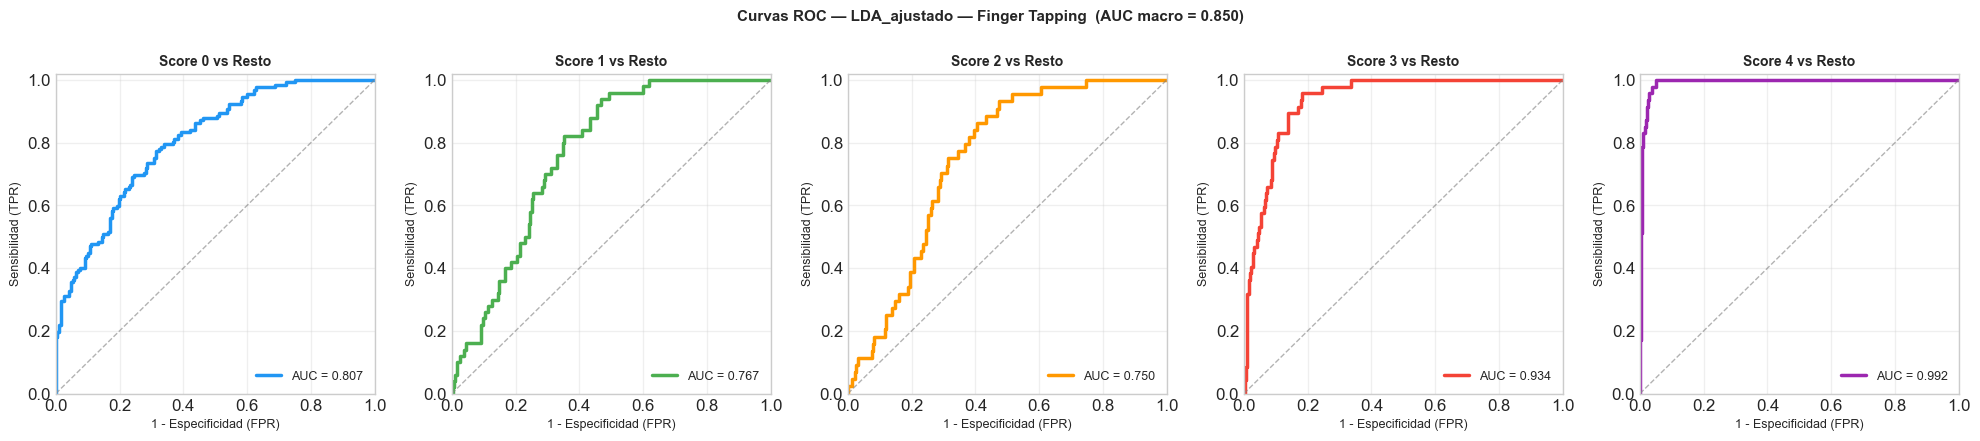

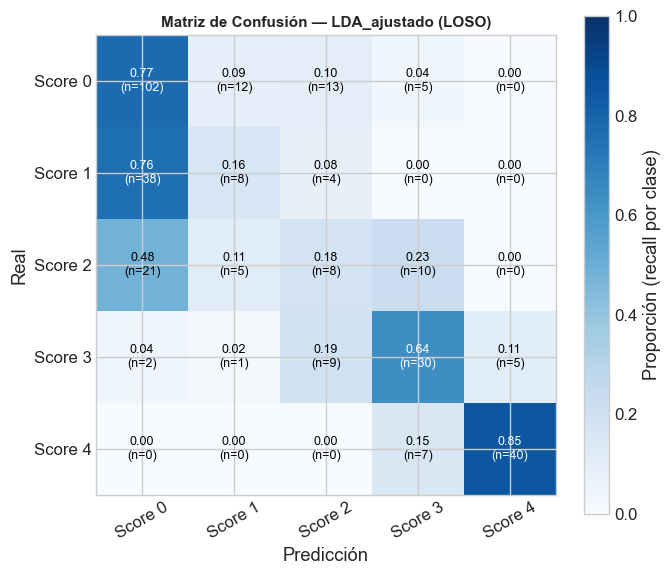


TABLA COMPARATIVA — 3 MODELOS (Finger Tapping)
      Modelo  Accuracy  AUC_macro  AUC_weighted  F1_macro    MCC  Acc_train    Gap
LDA_original    0.5094     0.7972        0.7750    0.4371 0.3087     0.7812 0.2719
KNN_original    0.5312     0.8215        0.8139    0.4259 0.3407     1.0000 0.4688
LDA_ajustado    0.5875     0.8497        0.8385    0.5166 0.4309     0.7969 0.2094

💾 Tabla guardada: ./resultados_golpeteo_completo/tablas/resumen_3modelos.csv


In [13]:
"""
============================================================================
CELDA 7 — ROC, AUC MULTICLASE Y MATRIZ DE CONFUSIÓN
ANÁLISIS PARALELO SOBRE LOS 3 MODELOS:
  • LDA_original  → entrenado sobre df_master (datos crudos)
  • KNN_original  → mejor k seleccionado en celda puente sobre df_master
  • LDA_ajustado  → entrenado sobre df_ajustado (amplitudes modificadas, EXPLORATORIO)
============================================================================
"""

# ── Consolidar resultados de los 3 modelos en un único diccionario ──────
mejor_k_knn = resultados_modelos['KNN']['k']

modelos_eval = {
    'LDA_original': {
        'y_true':  resultados_modelos['LDA']['resultado']['y_true'],
        'y_pred':  resultados_modelos['LDA']['resultado']['y_pred'],
        'y_proba': resultados_modelos['LDA']['resultado']['y_proba'],
        'clases':  resultados_modelos['LDA']['resultado']['clases'],
        'df_model': df_model,
        'metricas': resultados_modelos['LDA']['metricas'],
        'tipo': 'LDA',
        'descripcion': 'LDA shrinkage=0.95 sobre datos crudos',
    },
    'KNN_original': {
        'y_true':  resultados_modelos['KNN']['resultado']['y_true'],
        'y_pred':  resultados_modelos['KNN']['resultado']['y_pred'],
        'y_proba': resultados_modelos['KNN']['resultado']['y_proba'],
        'clases':  resultados_modelos['KNN']['resultado']['clases'],
        'df_model': df_model,
        'metricas': resultados_modelos['KNN']['metricas'],
        'tipo': 'KNN',
        'k': mejor_k_knn,
        'descripcion': f'KNN k={mejor_k_knn} weights=distance sobre datos crudos',
    },
    'LDA_ajustado': {
        'y_true':  y_true_adj,
        'y_pred':  y_pred_adj,
        'y_proba': y_proba_adj,
        'clases':  clases_adj,
        'df_model': df_model_adj,
        'metricas': calcular_metricas_completas({
    'y_true': y_true_adj, 'y_pred': y_pred_adj, 'y_proba': y_proba_adj,
    'clases': clases_adj, 'acc_train': acc_train_a, 'gap': gap_a
}),
        'tipo': 'LDA',
        'descripcion': 'LDA shrinkage=0.95 sobre amplitudes ajustadas (EXPLORATORIO)',
    },
}

# Factories reutilizables (para re-entrenar en por-mano e importancia)
def make_lda():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))])

def make_knn():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=mejor_k_knn,
                                                  weights='distance', metric='minkowski', p=2))])

factories = {
    'LDA_original': make_lda,
    'KNN_original': make_knn,
    'LDA_ajustado': make_lda,
}

print(f"✅ Consolidados {len(modelos_eval)} modelos en `modelos_eval`")
for n, info in modelos_eval.items():
    m = info['metricas']
    print(f"   {n:14s} | acc={m['accuracy']:.3f}  AUC={m['auc_macro']:.3f}  "
          f"F1={m['f1_macro']:.3f}  MCC={m['mcc']:.3f}  ({info['descripcion']})")


# ── Función genérica de ROC + matriz de confusión ───────────────────────
def graficar_roc_y_cm(nombre, info, ruta_fig):
    y_true_g  = info['y_true']
    y_pred_g  = info['y_pred']
    y_proba_g = info['y_proba']
    clases_clf = list(info['clases'])

    if len(y_true_g) == 0:
        print(f"⚠️  {nombre}: sin predicciones")
        return None

    scores_test = sorted(np.unique(y_true_g))
    n_c = len(scores_test)
    y_bin = label_binarize(y_true_g, classes=scores_test)

    # Alinear columnas de proba con scores_test usando las clases reales del clf
    idx = [clases_clf.index(s) if s in clases_clf else -1 for s in scores_test]
    y_proba_alin = np.zeros((len(y_proba_g), n_c))
    for j, k in enumerate(idx):
        if 0 <= k < y_proba_g.shape[1]:
            y_proba_alin[:, j] = y_proba_g[:, k]

    try:
        auc_macro    = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
        auc_weighted = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f"⚠️  AUC multiclase ({nombre}): {e}")
        auc_macro = auc_weighted = float('nan')

    # ── ROC ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n_c, figsize=(4*n_c, 4.5))
    if n_c == 1: axes = [axes]
    auc_por_score_loc = {}
    SCORE_COLORS_LOCAL = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
    for j, s in enumerate(scores_test):
        ax = axes[j]
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, j], y_proba_alin[:, j])
            a = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
            auc_por_score_loc[s] = a
            ax.plot(fpr, tpr, color=SCORE_COLORS_LOCAL.get(int(s), 'gray'), lw=2.5,
                    label=f'AUC = {a:.3f}')
        except Exception as e:
            auc_por_score_loc[s] = float('nan')
            ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center', transform=ax.transAxes)
        ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.6)
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xlabel('1 - Especificidad (FPR)', fontsize=9)
        ax.set_ylabel('Sensibilidad (TPR)', fontsize=9)
        ax.set_title(f'Score {s} vs Resto', fontsize=10, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

    fig.suptitle(f'Curvas ROC — {nombre} — Finger Tapping  (AUC macro = {auc_macro:.3f})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{ruta_fig}/roc_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ── Matriz de confusión normalizada ───────────────────────────────
    cm = confusion_matrix(y_true_g, y_pred_g, labels=scores_test)
    row_s = cm.sum(axis=1, keepdims=True); row_s[row_s == 0] = 1
    cm_norm = cm.astype(float) / row_s

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    im = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax2, label='Proporción (recall por clase)')
    tick = [f'Score {s}' for s in scores_test]
    ax2.set_xticks(range(n_c)); ax2.set_xticklabels(tick, rotation=30)
    ax2.set_yticks(range(n_c)); ax2.set_yticklabels(tick)
    ax2.set_xlabel('Predicción'); ax2.set_ylabel('Real')
    ax2.set_title(f'Matriz de Confusión — {nombre} (LOSO)', fontsize=11, fontweight='bold')
    for i in range(n_c):
        for j in range(n_c):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax2.text(j, i, f'{cm_norm[i, j]:.2f}\n(n={cm[i, j]})',
                     ha='center', va='center', fontsize=9, color=color)
    plt.tight_layout()
    fig2.savefig(f"{ruta_fig}/cm_{nombre}.png", dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'auc_macro': auc_macro,
        'auc_weighted': auc_weighted,
        'auc_por_score': auc_por_score_loc,
        'cm': cm,
        'scores_test': scores_test,
    }


# ── Ejecutar sobre los 3 modelos ────────────────────────────────────────
resultados_grafico = {}
for nombre, info in modelos_eval.items():
    print(f"\n{'='*70}\n  {nombre}  —  {info['descripcion']}\n{'='*70}")
    resultados_grafico[nombre] = graficar_roc_y_cm(
        nombre, info, f"{Config.RUTA_SALIDA}/figuras"
    )

# ── Tabla comparativa de los 3 modelos ──────────────────────────────────
filas = []
for nombre, info in modelos_eval.items():
    m = info['metricas']
    g = resultados_grafico[nombre]
    filas.append({
        'Modelo':        nombre,
        'Accuracy':      m['accuracy'],
        'AUC_macro':     g['auc_macro'] if g else float('nan'),
        'AUC_weighted':  g['auc_weighted'] if g else float('nan'),
        'F1_macro':      m['f1_macro'],
        'MCC':           m['mcc'],
        'Acc_train':     m.get('acc_train', float('nan')),
        'Gap':           m.get('gap', float('nan')),
    })
df_resumen_3modelos = pd.DataFrame(filas)
print("\n" + "="*70)
print("TABLA COMPARATIVA — 3 MODELOS (Finger Tapping)")
print("="*70)
print(df_resumen_3modelos.round(4).to_string(index=False))
df_resumen_3modelos.to_csv(f"{Config.RUTA_SALIDA}/tablas/resumen_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/resumen_3modelos.csv")

# ── Compatibilidad con celdas posteriores que usan variables sueltas ────
y_true_orig, y_pred_orig, y_proba_orig = y_true, y_pred, y_proba
auc_macro    = resultados_grafico['LDA_original']['auc_macro']
auc_weighted = resultados_grafico['LDA_original']['auc_weighted']
auc_por_score = resultados_grafico['LDA_original']['auc_por_score']

---
## CELDA 8 — Análisis por mano (derecha vs izquierda)

Manos presentes en dataset: ['left', 'right']


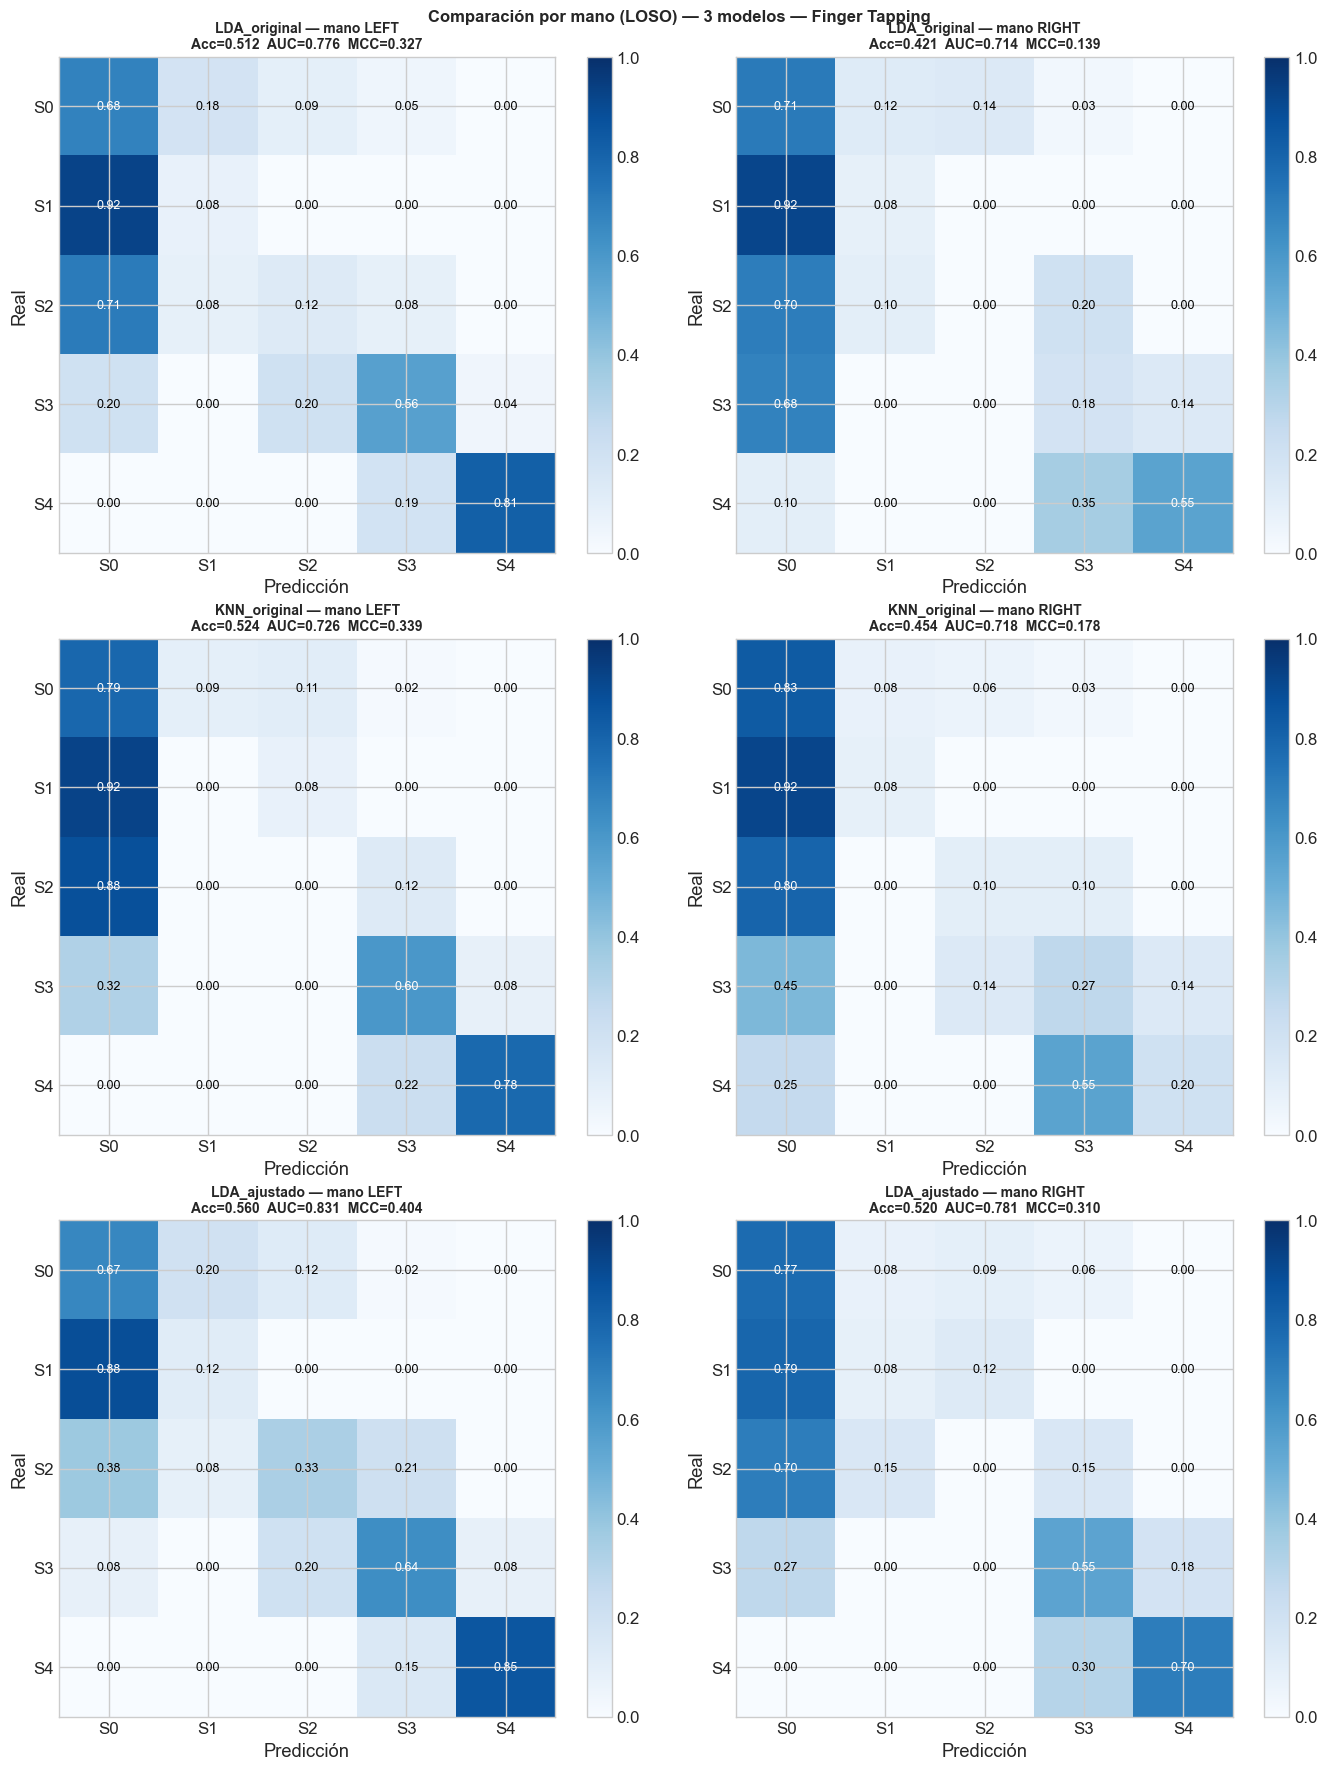


Resumen por mano y modelo:
      modelo  mano   n  accuracy  auc_macro    mcc
LDA_original  left 168    0.5119     0.7763 0.3272
LDA_original right 152    0.4211     0.7142 0.1387
KNN_original  left 168    0.5238     0.7257 0.3389
KNN_original right 152    0.4539     0.7184 0.1783
LDA_ajustado  left 168    0.5595     0.8305 0.4040
LDA_ajustado right 152    0.5197     0.7811 0.3095

💾 Tabla guardada: ./resultados_golpeteo_completo/tablas/comparacion_manos_3modelos.csv


In [14]:
"""
============================================================================
CELDA 8 — ANÁLISIS POR MANO (right vs left) — 3 MODELOS
Re-evalúa LOSO restringido a cada mano, para cada modelo.
Nota: LDA_ajustado usa df_model_adj (dataset exploratorio).
============================================================================
"""

manos_presentes = sorted([m for m in df_master['mano'].unique() if isinstance(m, str)])
print(f"Manos presentes en dataset: {manos_presentes}")

n_modelos = len(modelos_eval)
fig, axes_grid = plt.subplots(n_modelos, len(manos_presentes),
                              figsize=(7 * len(manos_presentes), 6 * n_modelos))
if n_modelos == 1:
    axes_grid = np.array([axes_grid])
if len(manos_presentes) == 1:
    axes_grid = axes_grid.reshape(-1, 1)

resumen_manos_3 = []
for i_m, (nombre, info) in enumerate(modelos_eval.items()):
    df_m_full = info['df_model']
    factory   = factories[nombre]

    for j_h, mano in enumerate(manos_presentes):
        ax = axes_grid[i_m, j_h]
        dfm = df_m_full[df_m_full['mano'] == mano]
        if len(dfm) < 10:
            ax.text(0.5, 0.5, f'mano={mano}\nn={len(dfm)} (insuf.)',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        Xm = dfm[Config.FEATURES_ANALISIS].values
        ym = dfm['score'].astype(int).values
        gm = dfm['sujeto'].values

        clf = factory()
        loso = LeaveOneGroupOut()
        yt, yp, ypr = [], [], []
        for tr, te in loso.split(Xm, ym, gm):
            if len(np.unique(ym[tr])) < 2:
                continue
            clf.fit(Xm[tr], ym[tr])
            yt.extend(ym[te])
            yp.extend(clf.predict(Xm[te]))
            ypr.extend(clf.predict_proba(Xm[te]))
        yt = np.array(yt); yp = np.array(yp); ypr = np.array(ypr)
        if len(yt) == 0:
            ax.text(0.5, 0.5, f'mano={mano}\nsin predicciones',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        scores_m = sorted(np.unique(yt))
        cm_m     = confusion_matrix(yt, yp, labels=scores_m)
        acc      = float(np.trace(cm_m)) / cm_m.sum()
        try:
            yb = label_binarize(yt, classes=scores_m)
            cls_clf = list(clf.named_steps['clf'].classes_)
            idx = [cls_clf.index(s) if s in cls_clf else -1 for s in scores_m]
            ypr_alin = np.zeros((len(ypr), len(scores_m)))
            for j, k in enumerate(idx):
                if 0 <= k < ypr.shape[1]:
                    ypr_alin[:, j] = ypr[:, k]
            auc_m = roc_auc_score(yb, ypr_alin, multi_class='ovr', average='macro')
        except Exception:
            auc_m = float('nan')

        try:
            mcc_m = matthews_corrcoef(yt, yp)
        except Exception:
            mcc_m = float('nan')

        resumen_manos_3.append({
            'modelo':    nombre,
            'mano':      mano,
            'n':         len(yt),
            'accuracy':  round(acc, 4),
            'auc_macro': round(auc_m, 4) if not np.isnan(auc_m) else None,
            'mcc':       round(mcc_m, 4) if not np.isnan(mcc_m) else None,
        })

        cm_norm = cm_m.astype(float) / np.maximum(cm_m.sum(axis=1, keepdims=True), 1)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax)
        tl = [f'S{s}' for s in scores_m]
        ax.set_xticks(range(len(scores_m))); ax.set_xticklabels(tl)
        ax.set_yticks(range(len(scores_m))); ax.set_yticklabels(tl)
        ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
        ax.set_title(f"{nombre} — mano {mano.upper()}\n"
                     f"Acc={acc:.3f}  AUC={auc_m:.3f}  MCC={mcc_m:.3f}",
                     fontsize=10, fontweight='bold')
        for i in range(len(scores_m)):
            for j in range(len(scores_m)):
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{cm_norm[i, j]:.2f}',
                        ha='center', va='center', color=color, fontsize=9)

fig.suptitle('Comparación por mano (LOSO) — 3 modelos — Finger Tapping',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_manos_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

df_manos_3 = pd.DataFrame(resumen_manos_3)
print("\nResumen por mano y modelo:")
print(df_manos_3.to_string(index=False))
df_manos_3.to_csv(f"{Config.RUTA_SALIDA}/tablas/comparacion_manos_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/comparacion_manos_3modelos.csv")

---
## CELDA 9 — Importancia de features (3 modelos)

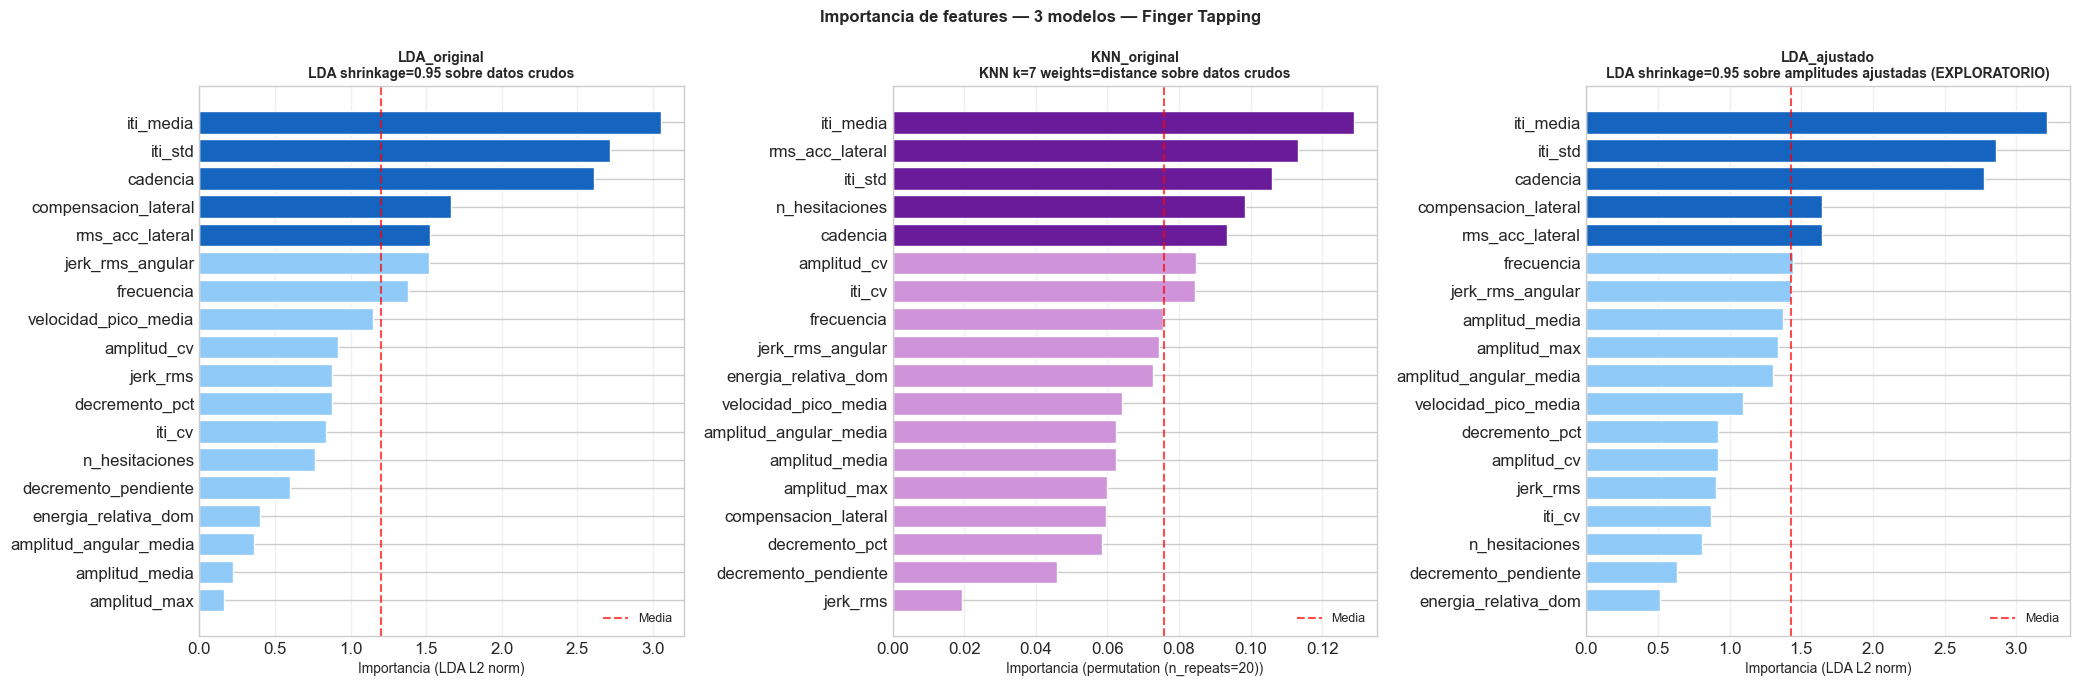


Top 10 features por modelo:

  LDA_original  (LDA L2 norm)
     1. iti_media                        3.0503
     2. iti_std                          2.7141
     3. cadencia                         2.6114
     4. compensacion_lateral             1.6633
     5. rms_acc_lateral                  1.5268
     6. jerk_rms_angular                 1.5160
     7. frecuencia                       1.3767
     8. velocidad_pico_media             1.1494
     9. amplitud_cv                      0.9155
    10. jerk_rms                         0.8802

  KNN_original  (permutation (n_repeats=20))
     1. iti_media                        0.1289
     2. rms_acc_lateral                  0.1133
     3. iti_std                          0.1059
     4. n_hesitaciones                   0.0984
     5. cadencia                         0.0934
     6. amplitud_cv                      0.0847
     7. iti_cv                           0.0845
     8. frecuencia                       0.0755
     9. jerk_rms_angular      

In [15]:
"""
============================================================================
CELDA 9 — IMPORTANCIA DE FEATURES — 3 MODELOS
  • LDA (original y ajustado): norma L2 de los coeficientes
  • KNN: permutation importance (n_repeats=20) sobre métrica accuracy
============================================================================
"""
from sklearn.inspection import permutation_importance

importancias = {}
fig, axes = plt.subplots(1, len(modelos_eval), figsize=(7 * len(modelos_eval), 7))
if len(modelos_eval) == 1:
    axes = [axes]

for ax, (nombre, info) in zip(axes, modelos_eval.items()):
    df_m = info['df_model']
    Xf = df_m[Config.FEATURES_ANALISIS].dropna().values
    yf = df_m.loc[df_m[Config.FEATURES_ANALISIS].dropna().index, 'score'].astype(int).values

    pipe = factories[nombre]()
    pipe.fit(Xf, yf)

    if info['tipo'] == 'LDA':
        clf = pipe.named_steps['clf']
        imp = np.linalg.norm(clf.coef_, axis=0)
        metodo = 'LDA L2 norm'
    else:  # KNN → permutation importance
        result = permutation_importance(pipe, Xf, yf, n_repeats=20,
                                        random_state=42, n_jobs=-1)
        imp = result.importances_mean
        metodo = 'permutation (n_repeats=20)'

    idx = np.argsort(imp)[::-1]
    feats_ord = [Config.FEATURES_ANALISIS[i] for i in idx]
    imps_ord  = imp[idx]

    importancias[nombre] = {
        'features': feats_ord,
        'valores':  imps_ord,
        'metodo':   metodo,
    }

    color_top  = '#1565C0' if 'LDA' in nombre else '#6A1B9A'
    color_rest = '#90CAF9' if 'LDA' in nombre else '#CE93D8'
    colors = [color_top if i < 5 else color_rest for i in range(len(feats_ord))]
    ax.barh(feats_ord[::-1], imps_ord[::-1], color=colors[::-1])
    ax.axvline(np.mean(imps_ord), color='red', ls='--', alpha=0.7, label='Media')
    ax.set_xlabel(f'Importancia ({metodo})', fontsize=10)
    ax.set_title(f'{nombre}\n{info["descripcion"]}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)

fig.suptitle('Importancia de features — 3 modelos — Finger Tapping',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla comparativa con top 10 features de cada modelo ────────────────
print("\nTop 10 features por modelo:")
filas_imp = []
for nombre, d in importancias.items():
    print(f"\n  {nombre}  ({d['metodo']})")
    for k, (f, v) in enumerate(zip(d['features'][:10], d['valores'][:10]), 1):
        print(f"    {k:2d}. {f:<32} {v:.4f}")
        filas_imp.append({'modelo': nombre, 'rank': k, 'feature': f,
                          'importancia': float(v), 'metodo': d['metodo']})
df_importancia_3 = pd.DataFrame(filas_imp)
df_importancia_3.to_csv(f"{Config.RUTA_SALIDA}/tablas/importancia_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/importancia_3modelos.csv")

---
## CELDA 10 — Correlación de Spearman: features vs score (3 datasets)

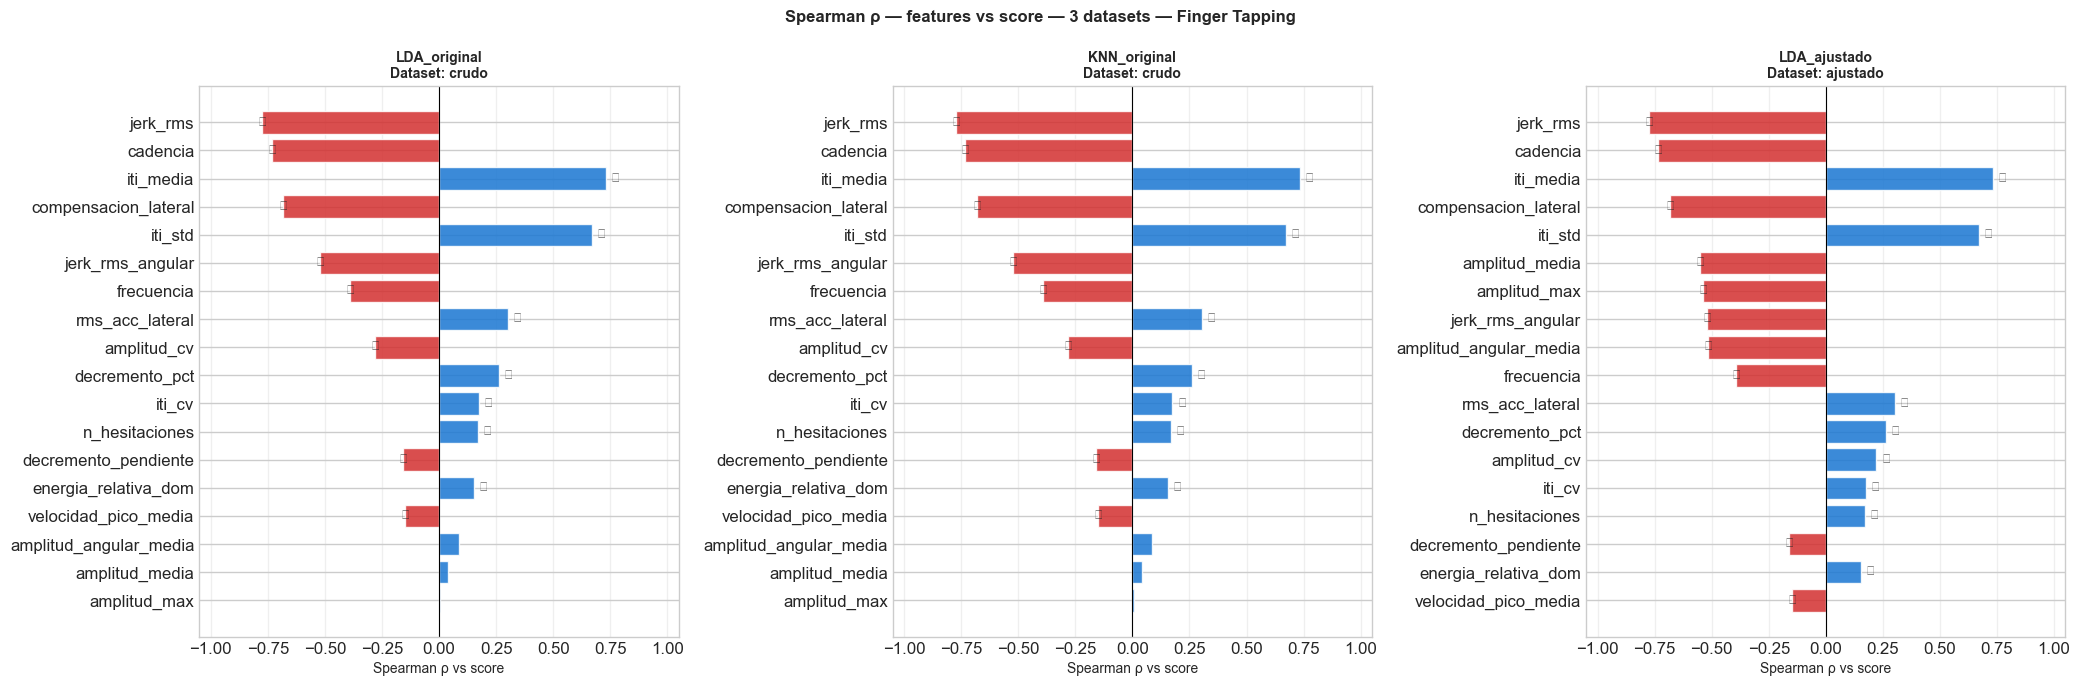


  Top 5 |ρ| — LDA_original
    jerk_rms                         ρ=-0.775  p=0.0000 ★
    cadencia                         ρ=-0.733  p=0.0000 ★
    iti_media                        ρ=+0.733  p=0.0000 ★
    compensacion_lateral             ρ=-0.683  p=0.0000 ★
    iti_std                          ρ=+0.671  p=0.0000 ★

  Top 5 |ρ| — KNN_original
    jerk_rms                         ρ=-0.775  p=0.0000 ★
    cadencia                         ρ=-0.733  p=0.0000 ★
    iti_media                        ρ=+0.733  p=0.0000 ★
    compensacion_lateral             ρ=-0.683  p=0.0000 ★
    iti_std                          ρ=+0.671  p=0.0000 ★

  Top 5 |ρ| — LDA_ajustado
    jerk_rms                         ρ=-0.775  p=0.0000 ★
    cadencia                         ρ=-0.733  p=0.0000 ★
    iti_media                        ρ=+0.733  p=0.0000 ★
    compensacion_lateral             ρ=-0.683  p=0.0000 ★
    iti_std                          ρ=+0.671  p=0.0000 ★

💾 Tabla guardada: ./resultados_golpeteo_compl

In [16]:
"""
============================================================================
CELDA 10 — CORRELACIÓN DE SPEARMAN: features vs score — 3 DATASETS
Spearman se calcula sobre el dataset que alimenta a cada modelo:
  • LDA_original / KNN_original → df_master  (datos crudos)
  • LDA_ajustado                → df_ajustado (amplitudes modificadas)
============================================================================
"""
from scipy.stats import spearmanr

# Cada modelo apunta al dataframe con todas sus filas (no solo df_model dropna)
datasets_spearman = {
    'LDA_original': df_master,
    'KNN_original': df_master,
    'LDA_ajustado': df_ajustado,
}

corr_por_modelo = {}
for nombre, df_src in datasets_spearman.items():
    rows = []
    for feat in Config.FEATURES_ANALISIS:
        v = df_src[feat].dropna()
        sc = df_src.loc[v.index, 'score']
        if len(v) > 5:
            rho, p = spearmanr(v, sc)
            rows.append({'feature': feat, 'rho': rho, 'p': p, 'abs_rho': abs(rho)})
    corr_por_modelo[nombre] = pd.DataFrame(rows).sort_values('abs_rho', ascending=False)

# ── Figura: una columna por modelo ──────────────────────────────────────
fig, axes = plt.subplots(1, len(corr_por_modelo), figsize=(7 * len(corr_por_modelo), 7),
                         sharey=False)
if len(corr_por_modelo) == 1:
    axes = [axes]

for ax, (nombre, dfc) in zip(axes, corr_por_modelo.items()):
    colores = ['#D32F2F' if r < 0 else '#1976D2' for r in dfc['rho']]
    ax.barh(dfc['feature'][::-1], dfc['rho'][::-1],
            color=colores[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim([-1.05, 1.05])
    ax.set_xlabel('Spearman ρ vs score', fontsize=10)
    ax.set_title(f'{nombre}\nDataset: {("ajustado" if "ajustado" in nombre else "crudo")}',
                 fontsize=10, fontweight='bold')
    for i, (_, row) in enumerate(dfc[::-1].iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + 0.02 * np.sign(row['rho']),
                    i, '★', fontsize=9, va='center')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Spearman ρ — features vs score — 3 datasets — Finger Tapping',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/spearman_3modelos.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla consolidada ───────────────────────────────────────────────────
filas_corr = []
for nombre, dfc in corr_por_modelo.items():
    print(f"\n  Top 5 |ρ| — {nombre}")
    for _, row in dfc.head(5).iterrows():
        sig = '★' if row['p'] < 0.05 else ' '
        print(f"    {row['feature']:<32} ρ={row['rho']:+.3f}  p={row['p']:.4f} {sig}")
        filas_corr.append({'modelo': nombre, **row.to_dict()})
    for _, row in dfc.iloc[5:].iterrows():
        filas_corr.append({'modelo': nombre, **row.to_dict()})

df_spearman_3 = pd.DataFrame(filas_corr)
df_spearman_3.to_csv(f"{Config.RUTA_SALIDA}/tablas/spearman_3modelos.csv", index=False)
print(f"\n💾 Tabla guardada: {Config.RUTA_SALIDA}/tablas/spearman_3modelos.csv")
print("★ = p < 0.05")

# ── Compatibilidad con celdas posteriores que usan `df_corr` ────────────
df_corr = corr_por_modelo['LDA_original']

---
## CELDA 11 — Exportación final y resumen ejecutivo

In [18]:
"""
============================================================================
CELDA 11 — EXPORTACIÓN FINAL (3 MODELOS) + RESUMEN EJECUTIVO
============================================================================
"""

import pickle as _pickle
import json as _json

# ── Verificar variables necesarias ───────────────────────────────────────
required = ['df_master', 'df_ajustado', 'df_descriptivo', 'df_kw',
            'df_resumen_3modelos', 'df_manos_3', 'modelos_eval',
            'resultados_grafico', 'importancias', 'corr_por_modelo',
            'factories']
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Faltan variables: {missing}. Ejecuta las celdas anteriores.")

timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/analisis_completo_3modelos_{timestamp}.xlsx"

print(f"Exportando Excel: {excel_path}")
print(f"  df_master shape  : {df_master.shape}")
print(f"  df_ajustado shape: {df_ajustado.shape}")

# ── Solo columnas numéricas + metadata (evita series temporales crudas) ──
cols_export = Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']
df_master_exp   = df_master[cols_export].copy()
df_ajustado_exp = df_ajustado[cols_export].copy()

print("  Escribiendo Excel (solo features numéricas)...")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    print("    → dataset_original")
    df_master_exp.to_excel(writer, sheet_name='dataset_original', index=False)

    print("    → dataset_ajustado_EXPLOR")
    df_ajustado_exp.to_excel(writer, sheet_name='dataset_ajustado_EXPLOR', index=False)

    print("    → descriptivo_por_score")
    df_descriptivo.to_excel(writer, sheet_name='descriptivo_por_score', index=False)

    print("    → kruskal_wallis")
    df_kw.to_excel(writer, sheet_name='kruskal_wallis', index=False)

    print("    → resumen_3modelos")
    df_resumen_3modelos.to_excel(writer, sheet_name='resumen_3modelos', index=False)

    print("    → por_mano_3modelos")
    df_manos_3.to_excel(writer, sheet_name='por_mano_3modelos', index=False)

    for nombre, info in modelos_eval.items():
        print(f"    → preds_{nombre}")
        pd.DataFrame({'y_real': info['y_true'], 'y_pred': info['y_pred']}).to_excel(
            writer, sheet_name=f'preds_{nombre}'[:31], index=False)

        g = resultados_grafico[nombre]
        if g:
            print(f"    → auc_{nombre}")
            df_auc = pd.DataFrame([
                {'score': s, 'auc_ovr': a,
                 'interpretacion': ('excelente' if a >= 0.9 else 'bueno' if a >= 0.8
                                    else 'aceptable' if a >= 0.7 else 'bajo')}
                for s, a in g['auc_por_score'].items()
            ])
            df_auc['auc_macro']    = g['auc_macro']
            df_auc['auc_weighted'] = g['auc_weighted']
            df_auc.to_excel(writer, sheet_name=f'auc_{nombre}'[:31], index=False)

        print(f"    → imp_{nombre}")
        imp = importancias[nombre]
        pd.DataFrame({'feature': imp['features'], 'importancia': imp['valores'],
                      'metodo': imp['metodo']}).to_excel(
            writer, sheet_name=f'imp_{nombre}'[:31], index=False)

        print(f"    → spearman_{nombre}")
        corr_por_modelo[nombre].to_excel(
            writer, sheet_name=f'spearman_{nombre}'[:31], index=False)

print(f"✅ Excel exportado: {excel_path}")

# ── Serializar modelos ────────────────────────────────────────────────────
print("\nSerializando modelos (pickle + metadata)...")
bundles = {}
import joblib
for nombre, info in modelos_eval.items():
    print(f"  → {nombre}")
    df_ok  = info['df_model'][Config.FEATURES_ANALISIS + ['score']].dropna()
    X_full = df_ok[Config.FEATURES_ANALISIS].values
    y_full = df_ok['score'].astype(int).values

    pipe = factories[nombre]()
    pipe.fit(X_full, y_full)

    pkl_path  = f"{Config.RUTA_SALIDA}/tablas/modelo_ft_{nombre}.pkl"
    meta_path = f"{Config.RUTA_SALIDA}/tablas/modelo_ft_{nombre}_metadata.json"

    with open(pkl_path, 'wb') as f:
        _pickle.dump(pipe, f)
        
    # ── Exportar también como joblib (formato compatible con lda_scorer) ──
    joblib_path = f"{Config.RUTA_SALIDA}/tablas/modelo_ft_{nombre}_bundle.joblib"
    
    # Extraer scaler y clf del pipeline
    scaler_step = pipe.named_steps.get('scaler', None)
    clf_step = pipe.named_steps['clf']
    
    joblib_bundle = {
        'scaler': scaler_step,
        'lda': clf_step,
        'feature_names': Config.FEATURES_ANALISIS,
        'pipeline': pipe,
        'classes': [int(c) for c in clf_step.classes_],
    }
    joblib.dump(joblib_bundle, joblib_path)
    print(f"      💾 {joblib_path}")

    # Create bundle entry early to avoid KeyError when assigning subkeys
    bundles[nombre] = {'pkl': pkl_path, 'meta': meta_path, 'joblib': joblib_path}

    m = info['metricas']
    g = resultados_grafico[nombre] or {}
    meta = {
        'modelo':          nombre,
        'descripcion':     info['descripcion'],
        'es_principal':    ('ajustado' not in nombre),
        'es_exploratorio': ('ajustado' in nombre),
        'feature_names':   Config.FEATURES_ANALISIS,
        'classes':         [int(c) for c in pipe.named_steps['clf'].classes_],
        'tarea':           'finger-tapping',
        'version':         '3.0',
        'dataset':         'ajustado' if 'ajustado' in nombre else 'original',
        'n_pruebas':       int(len(df_ok)),
        'metricas_loso': {
            'accuracy':  round(m['accuracy'], 4),
            'auc_macro': round(g.get('auc_macro', m['auc_macro']), 4),
            'f1_macro':  round(m['f1_macro'], 4),
            'mcc':       round(m['mcc'], 4),
            'gap_train': round(m.get('gap', float('nan')), 4),
        },
    }
    if 'k' in info:
        meta['k_neighbors'] = int(info['k'])

    with open(meta_path, 'w') as f:
        _json.dump(meta, f, indent=2)

    # bundles entry already present and includes joblib
    print(f"      💾 {pkl_path}")
# ── Resumen ejecutivo ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO — FINGER TAPPING MDS-UPDRS 3.4 (3 MODELOS)")
print("=" * 70)

print(f"\n📊 DATASET")
print(f"   Total pruebas válidas (original) : {len(df_master)}")
for s in Config.SCORES:
    n = len(df_master[df_master['score'] == s])
    print(f"   Score {s}                         : {n} pruebas")

print(f"\n📈 KRUSKAL-WALLIS")
sig_n = df_kw[df_kw['sig_nominal']]; sig_b = df_kw[df_kw['sig_bonf']]
print(f"   Features con p<0.05 (nominal)    : {len(sig_n)}/{len(df_kw)}")
print(f"   Features con p<0.05 (Bonferroni) : {len(sig_b)}/{len(df_kw)}")
print(f"   Features con efecto grande η²>0.14 : {len(df_kw[df_kw['efecto']=='grande'])}")

print(f"\n🎯 DISCRIMINABILIDAD (LOSO) — comparación 3 modelos")
print(df_resumen_3modelos.round(4).to_string(index=False))

print(f"\n🏆 MODELO PRINCIPAL RECOMENDADO PARA REPORTE:")
candidatos = df_resumen_3modelos[~df_resumen_3modelos['Modelo'].str.contains('ajustado')]
mejor_row = candidatos.loc[candidatos['AUC_macro'].astype(float).idxmax()]
print(f"   → {mejor_row['Modelo']}  (AUC macro = {mejor_row['AUC_macro']:.4f}, "
      f"MCC = {mejor_row['MCC']:.4f})")
print(f"\n⚠️  MODELO AJUSTADO (LDA_ajustado):")
print(f"   Es EXPLORATORIO. AUC reportado contiene señal inyectada por construcción")
print(f"   (reducción de amplitud + aumento de CV) y NO refleja la capacidad real")
print(f"   del sensor de discriminar severidad clínica.")

print(f"\n📁 Resultados en: {Config.RUTA_SALIDA}/")
print("=" * 70)

Exportando Excel: ./resultados_golpeteo_completo/analisis_completo_3modelos_20260517_194050.xlsx
  df_master shape  : (320, 28)
  df_ajustado shape: (320, 28)
  Escribiendo Excel (solo features numéricas)...
    → dataset_original
    → dataset_ajustado_EXPLOR
    → descriptivo_por_score
    → kruskal_wallis
    → resumen_3modelos
    → por_mano_3modelos
    → preds_LDA_original
    → auc_LDA_original
    → imp_LDA_original
    → spearman_LDA_original
    → preds_KNN_original
    → auc_KNN_original
    → imp_KNN_original
    → spearman_KNN_original
    → preds_LDA_ajustado
    → auc_LDA_ajustado
    → imp_LDA_ajustado
    → spearman_LDA_ajustado
✅ Excel exportado: ./resultados_golpeteo_completo/analisis_completo_3modelos_20260517_194050.xlsx

Serializando modelos (pickle + metadata)...
  → LDA_original
      💾 ./resultados_golpeteo_completo/tablas/modelo_ft_LDA_original_bundle.joblib
      💾 ./resultados_golpeteo_completo/tablas/modelo_ft_LDA_original.pkl
  → KNN_original
      💾 ./res

In [ ]:
# Los 3 bundles (pickle + metadata.json) ya se generaron en la celda anterior.
# Esta celda se conserva vacía para no romper la numeración de Notebook.
print("Bundles exportados en celda 11 — revisar carpeta tablas/:")
for nombre, paths in bundles.items():
    print(f"  • {nombre:14s} → {paths['pkl']}")

Bundles exportados en celda 11 — revisar carpeta tablas/:
  • LDA_original   → ./resultados_golpeteo_completo/tablas/modelo_ft_LDA_original.pkl
  • KNN_original   → ./resultados_golpeteo_completo/tablas/modelo_ft_KNN_original.pkl
  • LDA_ajustado   → ./resultados_golpeteo_completo/tablas/modelo_ft_LDA_ajustado.pkl
